# MICOM Community Modelling and Off-Flavor Analysis

**Project:** Cooperative Tradeoff Analysis of Consortia for Plant-Based Fermentation 


## 1. Setup

In [1]:
import os, warnings, cobra, micom, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import cobra.flux_analysis
from micom import Community
import micom.problems as _mp

RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

warnings.filterwarnings('ignore')

_lic = os.path.expanduser('~/gurobi.lic')
if os.path.exists(_lic):
    os.environ['GRB_LICENSE_FILE'] = _lic

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from legume_medium1_v2 import *

print(f'COBRApy: {cobra.__version__}')
print(f'MICOM:   {micom.__version__}')

COBRApy: 0.30.0
MICOM:   0.39.0


In [2]:
def fix_community_objective(com, ab_lp, ab_lm):
    """
    Explicitly set the community objective as a weighted sum of individual growth reactions.
    MICOM 0.39.0 can silently fail to map the iLP728 objective into the community LP - this function is the fix.
    """
    lp_g = next(r for r in com.reactions if 'Growth' in r.id and 'Lp' in r.id)
    lm_g = next(r for r in com.reactions if 'Growth' in r.id and 'Lm' in r.id)
    com.objective = ab_lp * lp_g.flux_expression + ab_lm * lm_g.flux_expression
    com.objective.direction = 'max'

_original_optimize = _mp.optimize_with_retry

def _patched_optimize(com, message=''):
    """
    Applies Gurobi numerical stability settings before each solver call.
    Required for the community LP, which is poorly conditioned at extreme
    abundance ratios.
    """
    com.solver.problem.Params.NumericFocus = 3
    com.solver.problem.Params.Method = 1
    com.solver.problem.Params.Presolve = 0
    return _original_optimize(com, message)

_mp.optimize_with_retry = _patched_optimize
print('Gurobi solver patch applied.')

Gurobi solver patch applied.


## 2. Model Preprocessing for MICOM

MICOM 0.39.0 builds the community objective by mapping each model's `objective.variables` into the merged LP. For `iLP728`, this mapping fails silently: the biomass reaction `biomass_LPL_RETB_t576_NoATP` had `lower_bound > 0` (forced sink), which MICOM relaxes to `lb=0` in `util.py:66`. After this relaxation, MICOM no longer associates the reaction with Lp's individual objective in the community LP — it treats it as a constraint rather than an objective variable. Result: μ=0 h⁻¹ for *L.plantarum* in all community simulations.

`preprocess_for_micom` resolves this before community construction: renames the objective reaction to `Growth` with `lb=0`, silences secondary biomass reactions, releases forced-sink lower bounds, and verifies solo growth > 0.1 h⁻¹ on a rich medium before writing the output file.

In [3]:
def preprocess_for_micom(xml_path: str,
                         growth_rxn_id: str,
                         apply_mn_fix: bool = False,
                         secondary_biomass_ids: list = None,
                         forced_sink_ids: list = None,
                         output_path: str = None) -> str:
    """
    Standardize a COBRApy model for MICOM 0.39.x community construction.

    Steps
    -----
    1. Rename the objective reaction to 'Growth' with lb=0.
    2. Silence secondary biomass reactions (ub=0).
    3. Release forced-sink lower bounds (lb > 0 → lb = 0).
    4. Verify solo growth > 0.1 h⁻¹ on a rich medium.
    5. Write and return the output path.

    Note: the file is saved with the model's original exchange bounds (restricted medium). 
    The legume medium is applied afterwards by set_community_medium — the bounds in the XML do not affect MICOM simulations.
    """
    model = cobra.io.read_sbml_model(xml_path)

    biomass_rxn = model.reactions.get_by_id(growth_rxn_id)
    biomass_rxn.id   = 'Growth'
    biomass_rxn.name = 'Growth'
    biomass_rxn.lower_bound = 0.0
    model.objective = 'Growth'

    for rxn_id in (secondary_biomass_ids or []):
        if rxn_id in model.reactions:
            rxn = model.reactions.get_by_id(rxn_id)
            rxn.upper_bound = 0.0
            rxn.lower_bound = 0.0

    for rxn_id in (forced_sink_ids or []):
        if rxn_id in model.reactions:
            rxn = model.reactions.get_by_id(rxn_id)
            if rxn.lower_bound > 0:
                rxn.lower_bound = 0.0

    if apply_mn_fix:
        for ion_id in ['EX_mg2_e', 'EX_mn2_e']:
            if ion_id in model.reactions:
                model.reactions.get_by_id(ion_id).lower_bound = -10.0

    # Verify solo growth on a rich medium (MRS-like: open all uptake exchanges)
    # Uses `with model:` context so the bounds are not saved to the output file.
    with model:
        _MRS_IONS = {
            'EX_h2o_e', 'EX_h_e', 'EX_nh4_e', 'EX_so4_e', 'EX_pi_e',
            'EX_mg2_e', 'EX_mn2_e', 'EX_na1_e', 'EX_fe2_e', 'EX_k_e',
            'EX_co2_e', 'EX_o2_e',
            # Koduru-specific ion variants
            'EX_mg_e', 'EX_o2_e',
        }
        _MRS_ORGANICS = [
            'EX_glc__D_e', 'EX_glc_e',
            'EX_ala__L_e', 'EX_arg__L_e', 'EX_asn__L_e', 'EX_asp__L_e',
            'EX_cys__L_e', 'EX_glu__L_e', 'EX_gln__L_e', 'EX_gly_e',
            'EX_his__L_e', 'EX_ile__L_e', 'EX_leu__L_e', 'EX_lys__L_e',
            'EX_met__L_e', 'EX_phe__L_e', 'EX_pro__L_e', 'EX_ser__L_e',
            'EX_thr__L_e', 'EX_trp__L_e', 'EX_tyr__L_e', 'EX_val__L_e',
            'EX_ade_e', 'EX_gua_e', 'EX_ura_e', 'EX_thymd_e',
            'EX_nac_e', 'EX_pnto__R_e', 'EX_ribflv_e', 'EX_thm_e',
        ]
        for rxn_id in (_MRS_IONS | set(_MRS_ORGANICS)):
            if rxn_id in model.reactions:
                model.reactions.get_by_id(rxn_id).lower_bound = -10.0

        sol = model.optimize()
        mu  = sol.objective_value if sol.status == 'optimal' else 0.0
        print(f'  Solo growth (rich MRS medium): μ = {mu:.4f} h⁻¹ ({sol.status})')
        assert mu > 0.1, (
            f'Insufficient solo growth after preprocessing: μ={mu:.4f} h⁻¹\n'
            f'Check that growth_rxn_id is correct and the model is viable.')

    if output_path is None:
        output_path = xml_path.replace('.xml', '_micom_ready.xml')
    cobra.io.write_sbml_model(model, output_path)
    return output_path

# L.plantarum: iLP728 has multiple exchange reactions with forced-sink lb > 0
LP_FORCED_SINKS = [
    'EX_asp__L_e', 'EX_met__L_e', 'EX_etoh_e',   'EX_for_e',
    'EX_arg__L_e', 'EX_ac_e',     'EX_lac__D_e',  'EX_acald_e',
    'EX_succ_e',   'EX_actn__R_e', 'EX_nh4_e',    'EX_pyr_e',
    'EX_lac__L_e',
]

lp_ready_path = preprocess_for_micom(
    xml_path              = '../models/curated/iLP728_curated_v2.xml',
    growth_rxn_id         = 'biomass_LPL_RETB_t576_NoATP',
    secondary_biomass_ids = ['biomass_LPL60'],
    forced_sink_ids       = LP_FORCED_SINKS,
    output_path           = '../models/curated/iLP728_micom_ready.xml',
    apply_mn_fix          = True,
)

# L.mesenteroides: identify objective reaction dynamically
lm_test     = cobra.io.read_sbml_model('../models/curated/Koduru2022_curated_v2.xml')
lm_obj_rxns = [rxn.id for rxn in lm_test.reactions if rxn.objective_coefficient > 0]
print(f'L.mesenteroides objective reactions: {lm_obj_rxns}')

lm_ready_path = preprocess_for_micom(
    xml_path      = '../models/curated/Koduru2022_curated_v2.xml',
    growth_rxn_id = lm_obj_rxns[0],
    output_path   = '../models/curated/Koduru_micom_ready.xml',
)

print(f'\nL.plantarum ready: {lp_ready_path}')
print(f'L.mesenteroides ready: {lm_ready_path}')

Set parameter Username
Set parameter LicenseID to value 2818537
Academic license - for non-commercial use only - expires 2027-05-05
  Solo growth (rich MRS medium): μ = 0.9734 h⁻¹ (optimal)
L.mesenteroides objective reactions: ['biomass']
  Solo growth (rich MRS medium): μ = 1.5899 h⁻¹ (optimal)

L.plantarum ready: ../models/curated/iLP728_micom_ready.xml
L.mesenteroides ready: ../models/curated/Koduru_micom_ready.xml


## 3. Community Construction

The community is built with `progress=False` for non-interactive execution. After construction, `com.objectives` is checked explicitly for both organisms. If *L.plantarum*'s entry is `None` (silent MICOM failure), `fix_community_objective` injects the correct objective directly from the merged model's reactions.

In [4]:
taxonomy = pd.DataFrame([
    {'id': 'Lp', 'genus': 'Lactiplantibacillus', 'species': 'plantarum',
     'abundance': 0.5, 'file': lp_ready_path},
    {'id': 'Lm', 'genus': 'Leuconostoc', 'species': 'mesenteroides',
     'abundance': 0.5, 'file': lm_ready_path},
])

com = Community(taxonomy, progress=False, solver='gurobi')
DEFAULT_MEDIUM = dict(com.medium)

print(f'Organisms: {com.taxa}')
print(f'Community exchanges: {len(com.exchanges)}')
print(f'Default medium: {len(DEFAULT_MEDIUM)} exchanges')

fix_community_objective(com, 0.5, 0.5)
print('Community objective set.')

Organisms: ['Lp', 'Lm']
Community exchanges: 193
Default medium: 67 exchanges
Community objective set.


## 4. Legume Medium Construction

`community.medium` in MICOM 0.39.0 includes both the community-level `_m` exchanges (shared pool) and per-organism `_e` exchanges (internal routing between intracellular space and the pool). Assigning a dict to the `.medium` setter closes any `_e` reaction absent from the dict, severing each organism's metabolic connection to the shared pool.

`set_community_medium` avoids this by injecting bounds directly onto exchange reactions, without using the setter. Only `_m` exchanges are affected.

In [5]:
_ALWAYS_KEEP_M = {
    'EX_h2o_m', 'EX_h_m',   'EX_nh4_m',  'EX_so4_m',
    'EX_pi_m',  'EX_mn2_m', 'EX_na1_m',  'EX_fe2_m',
    'EX_k_m',   'EX_mg2_m', 'EX_co2_m',  'EX_o2_m',
}

# Nucleobases and vitamins required as auxotrophic supplements for L.plantarum (WCFS1) and L.mesenteroides. 
LAB_AUXOTROPHY_M = [
    'EX_ade_m', 'EX_gua_m', 'EX_ura_m',    'EX_thymd_m',
    'EX_hxan_m','EX_ins_m', 'EX_asn__L_m', 'EX_gln__L_m',
    'EX_pnto__R_m', 'EX_nac_m',
]

# Koduru-specific ions and cofactors kept open regardless of legume content
KODURU_KEEP = {
    'EX_Co2_m', 'EX_Mo2_m', 'EX_Ni2_m',
    'EX_cl_m',  'EX_h2s_m', 'EX_zn2_m',
    'EX_pnto-R_m', 'EX_pydam_m', 'EX_orot_m',
    'EX_xan_m', 'EX_cit_m', 'EX_4abz_m',
}

AA_STEMS = [
    'ala','arg','asn','asp','cys','gln','glu','gly',
    'his','ile','leu','lys','met','phe','pro','ser',
    'thr','trp','tyr','val',
]


def build_micom_medium(composicao_dict, mapa_lp_e, mapa_lm_e,
                       MW_dict, ex_ids_micom):
    """
    Convert nutritional composition (mg/kg DM) to a MICOM medium dict.
    Returns {EX_met_m: max_uptake_flux (mmol/gCDW/h)}.
    """
    ex_ids_set = set(ex_ids_micom)
    medium = {}

    for ex_id in _ALWAYS_KEEP_M:
        if ex_id in ex_ids_set:
            medium[ex_id] = (1000.0 if any(s in ex_id for s in ['h2o','h_m','co2'])
                             else 10.0)
    if 'EX_o2_m' in ex_ids_set:
        medium['EX_o2_m'] = 1.0

    for mid in LAB_AUXOTROPHY_M:
        if mid in ex_ids_set:
            medium[mid] = 1.0

    nao_mapeados = []
    for composto, C_mgkg in composicao_dict.items():
        if composto not in MW_dict:
            continue
        max_uptake = abs(calcular_bound(C_mgkg, MW_dict[composto]))
        aplicado   = False
        for mapa in [mapa_lp_e, mapa_lm_e]:
            ex_id_e = mapa.get(composto)
            if ex_id_e is None:
                continue
            mid = ex_id_e[:-2] + '_m' if ex_id_e.endswith('_e') else ex_id_e
            if mid in ex_ids_set:
                medium[mid] = max(medium.get(mid, 0.0), max_uptake)
                aplicado = True
        if not aplicado:
            nao_mapeados.append(composto)

    if nao_mapeados:
        print(f'  No community exchange for ({len(nao_mapeados)}): {nao_mapeados}')
    return medium


def set_community_medium(community, legume_medium, default_medium):
    """
    Apply legume medium to the MICOM community. 
    Injects bounds directly — never assigns to community.medium setter to avoid closing per-organism _e routing reactions.
    """
    for rxn in community.exchanges:
        if rxn.upper_bound < 0:
            rxn.upper_bound = 0.0

    m_ids  = {rxn.id for rxn in community.exchanges if rxn.id.endswith('_m')}
    merged = {}

    for ex_id, val in default_medium.items():
        if ex_id in m_ids:
            merged[ex_id] = val
    for ex_id, val in legume_medium.items():
        if ex_id in m_ids:
            merged[ex_id] = val

    for ex_id, val in default_medium.items():
        if not ex_id.endswith('_m') or val <= 0:
            continue
        if ex_id in legume_medium or ex_id in _ALWAYS_KEEP_M or ex_id in KODURU_KEEP:
            continue
        stem = (ex_id.replace('EX_','').replace('_m','')
                     .replace('__L','').replace('-L','').lower())
        if any(aa in stem for aa in AA_STEMS):
            continue
        merged[ex_id] = 0.0

    for ex in community.exchanges:
        if ex.id in merged:
            ex.lower_bound = -merged[ex.id]


# Build medium dicts for both matrices
ex_ids_all = [r.id for r in com.exchanges]
medium_cp  = build_micom_medium(chickpea_max, mapa_ilp728, mapa_koduru, MW, ex_ids_all)
medium_fb  = build_micom_medium(favabean_max, mapa_ilp728, mapa_koduru, MW, ex_ids_all)

print(f'Chickpea medium:  {sum(1 for v in medium_cp.values() if v > 0)} active exchanges')
print(f'Fava bean medium: {sum(1 for v in medium_fb.values() if v > 0)} active exchanges')

# Critical metabolite check
criticos = {
    'glucose':   'EX_glc__D_m', 'glutamato': 'EX_glu__L_m',
    'leucina':   'EX_leu__L_m', 'fosfato':   'EX_pi_m',
    'NH4':       'EX_nh4_m',    'sacarose':  'EX_sucr_m',
    'rafinose':  'EX_raffin_m',
}
print('\nCritical metabolite check (chickpea):')
for label, mid in criticos.items():
    val = medium_cp.get(mid)
    print(f'  {label:<12} {mid:<22} '
          f'{f"{val:.6f}" if val is not None else "absent"}')

# Sanity check: Eq50 chickpea — both strains must grow
print('\nSanity check: chickpea Eq50')
com_test     = Community(taxonomy, progress=False, solver='gurobi')
default_snap = dict(com_test.medium)
com_test.set_abundance({'Lp': 0.5, 'Lm': 0.5}, normalize=True)
set_community_medium(com_test, medium_cp, default_snap)
sol_test = com_test.cooperative_tradeoff(fraction=0.5)
print(f'  Status: {sol_test.status}')
if sol_test.status == 'optimal':
    print(f'  Lp: {sol_test.members.loc["Lp","growth_rate"]:.4f} h⁻¹')
    print(f'  Lm: {sol_test.members.loc["Lm","growth_rate"]:.4f} h⁻¹')
    assert sol_test.members.loc['Lp','growth_rate'] > 1e-6
    assert sol_test.members.loc['Lm','growth_rate'] > 1e-6
    print('  Both grow — medium pipeline OK.')

  No community exchange for (2): ['ascorbato', 'magnesio']
  No community exchange for (2): ['ascorbato', 'magnesio']
Chickpea medium:  56 active exchanges
Fava bean medium: 54 active exchanges

Critical metabolite check (chickpea):
  glucose      EX_glc__D_m            1.027893
  glutamato    EX_glu__L_m            5.286330
  leucina      EX_leu__L_m            2.823591
  fosfato      EX_pi_m                10.000000
  NH4          EX_nh4_m               10.000000
  sacarose     EX_sucr_m              1.623008
  rafinose     EX_raffin_m            absent

Sanity check: chickpea Eq50
  Status: optimal
  Lp: 0.4390 h⁻¹
  Lm: 0.4390 h⁻¹
  Both grow — medium pipeline OK.


## 5. Solo COBRApy Validation

Solo growth rates on the legume medium (`chickpea_max`, `favabean_max`, `_max` composition scenario, `aa_lp=aa_lm=0.25`) computed with COBRApy. These values serve as the baseline for the solo vs. consortium comparison.

In [6]:
modelos_cobra = {
    'L.plantarum': (cobra.io.read_sbml_model('../models/curated/iLP728_curated_v2.xml'),
           mapa_ilp728, 'ilp728'),
    'L.mesenteroides': (cobra.io.read_sbml_model('../models/curated/Koduru2022_curated_v2.xml'),
           mapa_koduru, 'koduru'),
}

print('=== Solo validation (COBRApy) ===\n')
solo_computed = {'L.plantarum': {}, 'L.mesenteroides': {}}

for nome_matriz, composicao in [('chickpea', chickpea_max), ('fava_bean', favabean_max)]:
    print(f'--- {nome_matriz} ---')
    for org, (modelo, mapa, tipo) in modelos_cobra.items():
        m   = modelo.copy()
        aplicar_meio_leguminosa(m, composicao, mapa,
                                nome_matriz=nome_matriz, modelo_tipo=tipo,
                                verbose=False)
        sol = m.optimize()
        mu  = sol.objective_value if sol.status == 'optimal' else None
        solo_computed[org][nome_matriz] = mu
        print(f'  {org}: μ = {mu:.4f} h⁻¹' if mu is not None else f'  {org}: Infeasible')
    print()

print('Solo references for Section 9:')
for org in ['L.plantarum', 'L.mesenteroides']:
    for mat in ['chickpea', 'fava_bean']:
        print(f'  {org} {mat}: {solo_computed[org][mat]:.4f} h⁻¹')

=== Solo validation (COBRApy) ===

--- chickpea ---
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/pc/ykhcdwt55sv66yd1qmdsb5q80000gn/T/tmpj05nv8z2.lp
Reading time = 0.00 seconds
: 672 rows, 1570 columns, 6422 nonzeros
  L.plantarum: μ = 0.5645 h⁻¹
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/pc/ykhcdwt55sv66yd1qmdsb5q80000gn/T/tmp34oapseq.lp
Reading time = 0.00 seconds
: 926 rows, 2224 columns, 9300 nonzeros
  L.mesenteroides: μ = 0.1076 h⁻¹

--- fava_bean ---
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/pc/ykhcdwt55sv66yd1qmdsb5q80000gn/T/tmpmdldscr_.lp
Reading time = 0.00 seconds
: 672 rows, 1570 columns, 6422 nonzeros
  L.plantarum: μ = 0.3411 h⁻¹
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/pc/ykhcdwt55sv66yd1qmdsb5q8000

## 6. Abundance Sweep

Three abundance ratios (Lp75/Eq50/Lm75) × two matrices (chickpea/fava bean) = 6 configurations. Each uses `cooperative_tradeoff(fraction=0.5)` — a Pareto-optimal allocation that guarantees at least 50% of the theoretical maximum growth rate for both organisms simultaneously.

Growth rates that scale proportionally with the abundance ratio (Lp75 > Eq50 > Lm75 for L.plantarum) are a structural property of the cooperative tradeoff objective, not strain-differential biology. The interpretable signal is `delta_pct` relative to the solo baseline (Section 9).

In [7]:
TRADEOFF = 0.5

ABUNDANCE_RATIOS = {
    'Lp75': (0.75, 0.25),
    'Eq50': (0.50, 0.50),
    'Lm75': (0.25, 0.75),
}

configs = {}
for ratio_name, (ab_lp, ab_lm) in ABUNDANCE_RATIOS.items():
    for matrix_name, medium in [('chickpea', medium_cp), ('fava_bean', medium_fb)]:
        configs[f'{ratio_name}_{matrix_name}'] = {
            'Lp': ab_lp, 'Lm': ab_lm,
            'matrix': matrix_name, 'medium': medium,
        }

# Target metabolites — only those present in the community model
_TARGETS_CANDIDATE = {
    'lactate_L':          'EX_lac__L_m',
    'lactate_D':          'EX_lac__D_m',
    'ethanol':            'EX_etoh_m',
    'acetate':            'EX_ac_m',
    'CO2':                'EX_co2_m',
    'formate':            'EX_for_m',
    'acetoin':            'EX_actn__R_m',
    'mannitol':           'EX_mnl_m',
    'succinate':          'EX_succ_m',
    'pyruvate':           'EX_pyr_m',
    'alanine':            'EX_ala__L_m',
    'glutamate':          'EX_glu__L_m',
    'leucine':            'EX_leu__L_m',
    '3_methylbutanoate':  'EX_3mba_m',
    '2_methylbutanoate':  'EX_2mba_m',
    '2_methylpropanoate': 'EX_2mpa_m',
    '3_methylbutanal':    'EX_3mbal_m',
    '2_methylbutanal':    'EX_2mbal_m',
    'hexanol':            'EX_hxol_m',
}

ex_ids_set      = {r.id for r in com.exchanges}
METABOLITOS_ALVO = {k: v for k, v in _TARGETS_CANDIDATE.items() if v in ex_ids_set}
absent           = set(_TARGETS_CANDIDATE) - set(METABOLITOS_ALVO)
print(f'Target metabolites tracked: {len(METABOLITOS_ALVO)}')
if absent:
    print(f'Absent from community model (skipped): {sorted(absent)}')

resultados = []
print(f'\nRunning {len(configs)} configs at tradeoff={TRADEOFF}...')

for nome_cfg, cfg in configs.items():
    com_cfg     = Community(taxonomy, progress=False, solver='gurobi')
    default_cfg = dict(com_cfg.medium)
    com_cfg.set_abundance({'Lp': cfg['Lp'], 'Lm': cfg['Lm']}, normalize=True)
    set_community_medium(com_cfg, cfg['medium'], default_cfg)

    try:
        sol = com_cfg.cooperative_tradeoff(fraction=TRADEOFF, fluxes=True)
    except Exception as exc:
        print(f'  {nome_cfg}: solver error — {exc}')
        resultados.append({'config': nome_cfg, 'status': 'error',
                           'matrix': cfg['matrix'],
                           'ab_Lp': cfg['Lp'], 'ab_Lm': cfg['Lm']})
        continue

    row = {
        'config':   nome_cfg,  'matrix':   cfg['matrix'],
        'ab_Lp':    cfg['Lp'], 'ab_Lm':    cfg['Lm'],
        'tradeoff': TRADEOFF,  'status':   sol.status,
        'mu_Lp': (sol.members.loc['Lp','growth_rate']
                  if sol.status == 'optimal' else None),
        'mu_Lm': (sol.members.loc['Lm','growth_rate']
                  if sol.status == 'optimal' else None),
    }

    if sol.status == 'optimal' and sol.fluxes is not None:
        for nome_met, ex_id in METABOLITOS_ALVO.items():
            total = 0.0
            for org in ['Lp', 'Lm']:
                try:
                    val = sol.fluxes.loc[org, ex_id]
                    if val is not None and not np.isnan(float(val)):
                        total += float(val)
                except (KeyError, TypeError):
                    pass
            row[f'{nome_met}_total'] = round(total, 6)
        row['_fluxes'] = sol.fluxes.copy()

    resultados.append(row)
    mu_lp = f"{row['mu_Lp']:.4f}" if row.get('mu_Lp') is not None else 'N/A'
    mu_lm = f"{row['mu_Lm']:.4f}" if row.get('mu_Lm') is not None else 'N/A'
    print(f'  {nome_cfg:<28}  Lp={int(cfg["Lp"]*100):2d}%  Lm={int(cfg["Lm"]*100):2d}%  '
          f'mu_Lp={mu_lp}  mu_Lm={mu_lm}')

df_results = pd.DataFrame(
    [{k: v for k, v in r.items() if k != '_fluxes'} for r in resultados])
df_results.to_csv(f'{RESULTS_DIR}/obj4_abundance_sweep.csv', index=False)

n_optimal = sum(1 for r in resultados if r.get('status') == 'optimal')
print(f'\n{n_optimal}/{len(resultados)} configs solved optimally.')
cols = [c for c in ['config','matrix','ab_Lp','ab_Lm','mu_Lp','mu_Lm','status']
        if c in df_results.columns]
print(df_results[cols].to_string(index=False))

Target metabolites tracked: 17
Absent from community model (skipped): ['2_methylbutanal', '3_methylbutanal']

Running 6 configs at tradeoff=0.5...
  Lp75_chickpea                 Lp=75%  Lm=25%  mu_Lp=0.5310  mu_Lm=0.1770
  Lp75_fava_bean                Lp=75%  Lm=25%  mu_Lp=0.3482  mu_Lm=0.1161
  Eq50_chickpea                 Lp=50%  Lm=50%  mu_Lp=0.4390  mu_Lm=0.4390
  Eq50_fava_bean                Lp=50%  Lm=50%  mu_Lp=0.2875  mu_Lm=0.2875
  Lm75_chickpea                 Lp=25%  Lm=75%  mu_Lp=0.1742  mu_Lm=0.5225
  Lm75_fava_bean                Lp=25%  Lm=75%  mu_Lp=0.1139  mu_Lm=0.3418

6/6 configs solved optimally.
        config    matrix  ab_Lp  ab_Lm    mu_Lp    mu_Lm  status
 Lp75_chickpea  chickpea   0.75   0.25 0.531029 0.177010 optimal
Lp75_fava_bean fava_bean   0.75   0.25 0.348233 0.116078 optimal
 Eq50_chickpea  chickpea   0.50   0.50 0.438976 0.438976 optimal
Eq50_fava_bean fava_bean   0.50   0.50 0.287515 0.287515 optimal
 Lm75_chickpea  chickpea   0.25   0.75 0.174172

## 7. Abundance sweep visualization

Line and grouped-bar charts of consortium growth rates per abundance ratio and matrix, with solo references (Section 5) overlaid as dashed lines. Built from the `df_results` table computed in Section 6.

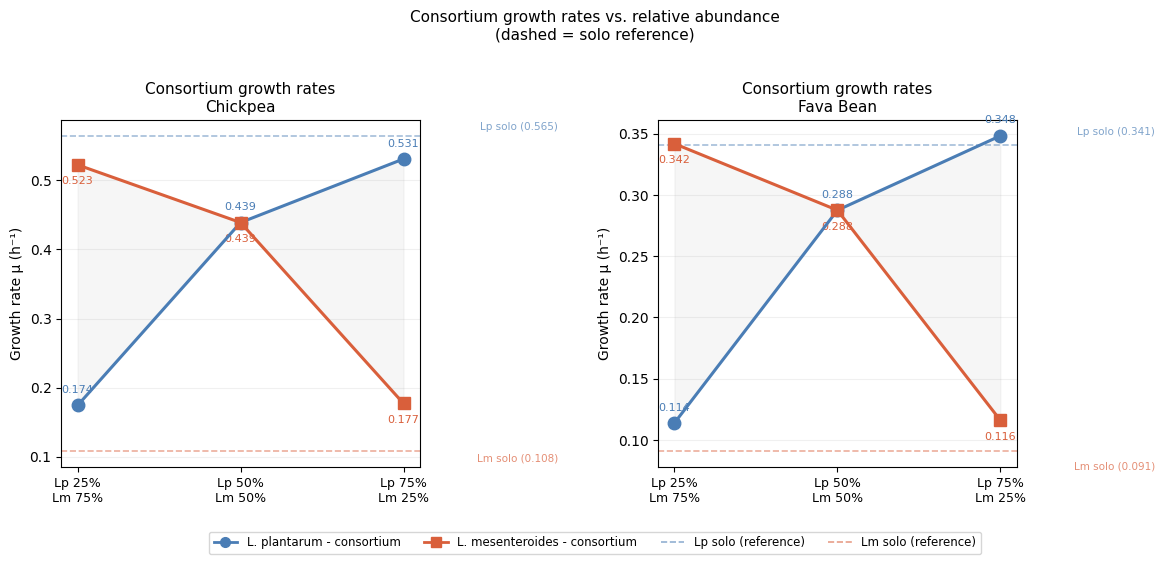

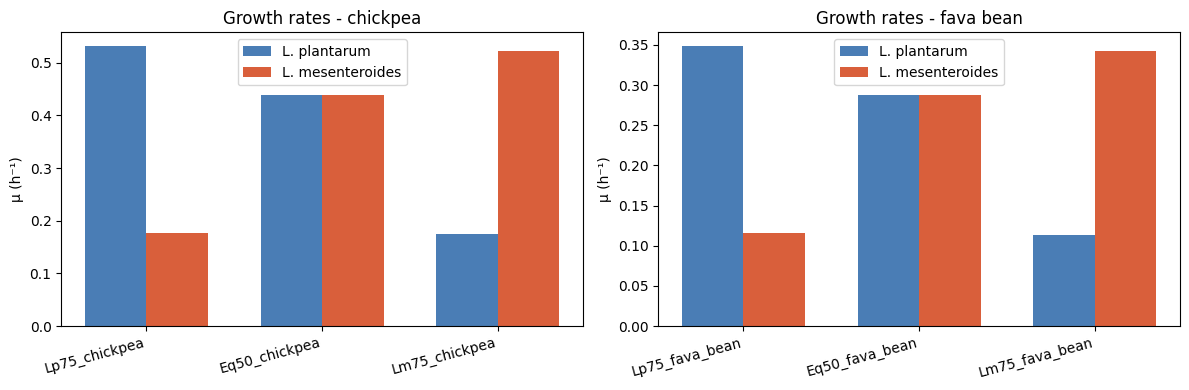

Figures saved.


In [8]:
COL_LP   = '#4A7DB5'
COL_LM   = '#D95F3B'
COL_GRID = '#F0F0F0'

def plot_growth_lines(df_results, solo_computed, save_dir='results'):
    matrizes  = df_results['matrix'].unique()
    fig, axes = plt.subplots(1, len(matrizes), figsize=(6*len(matrizes), 5),
                             sharey=False)
    if len(matrizes) == 1:
        axes = [axes]

    ordem_ratio = ['Lm75', 'Eq50', 'Lp75']

    for ax, mat in zip(axes, matrizes):
        sub = df_results[df_results['matrix'] == mat].copy()
        sub['ratio'] = sub['config'].apply(
            lambda c: next((r for r in ordem_ratio if c.startswith(r)), c))
        sub = (sub.set_index('ratio')
                  .reindex([r for r in ordem_ratio if r in sub['ratio'].values])
                  .reset_index())

        x     = np.arange(len(sub))
        mu_lp = sub['mu_Lp'].tolist()
        mu_lm = sub['mu_Lm'].tolist()

        ax.plot(x, mu_lp, 'o-', color=COL_LP, linewidth=2.2, markersize=9,
                zorder=4, label='L. plantarum')
        ax.plot(x, mu_lm, 's-', color=COL_LM, linewidth=2.2, markersize=9,
                zorder=4, label='L. mesenteroides')

        solo_lp = solo_computed['L.plantarum'][mat]
        solo_lm = solo_computed['L.mesenteroides'][mat]
        ax.axhline(solo_lp, color=COL_LP, linewidth=1.2, linestyle='--', alpha=0.5)
        ax.axhline(solo_lm, color=COL_LM, linewidth=1.2, linestyle='--', alpha=0.5)
        ax.text(len(x)-0.05, solo_lp+0.008, f'Lp solo ({solo_lp:.3f})',
                ha='right', fontsize=7.5, color=COL_LP, alpha=0.7)
        ax.text(len(x)-0.05, solo_lm-0.015, f'Lm solo ({solo_lm:.3f})',
                ha='right', fontsize=7.5, color=COL_LM, alpha=0.7)

        for xi, (ylp, ylm) in enumerate(zip(mu_lp, mu_lm)):
            ax.annotate(f'{ylp:.3f}', (xi, ylp), textcoords='offset points',
                        xytext=(0, 9), ha='center', fontsize=8, color=COL_LP)
            ax.annotate(f'{ylm:.3f}', (xi, ylm), textcoords='offset points',
                        xytext=(0,-14), ha='center', fontsize=8, color=COL_LM)

        labels = [r.replace('Lp75','Lp 75%\nLm 25%')
                   .replace('Eq50','Lp 50%\nLm 50%')
                   .replace('Lm75','Lp 25%\nLm 75%')
                  for r in sub['ratio'].tolist()]
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_ylabel('Growth rate μ (h⁻¹)', fontsize=10)
        ax.set_title(f'Consortium growth rates\n{mat.replace("_"," ").title()}',
                     fontsize=11)
        ax.yaxis.grid(True, color=COL_GRID, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.fill_between(x, mu_lp, mu_lm, alpha=0.07, color='#888')

    handles = [
        mlines.Line2D([], [], color=COL_LP, marker='o', linewidth=2,
                      markersize=7, label='L. plantarum - consortium'),
        mlines.Line2D([], [], color=COL_LM, marker='s', linewidth=2,
                      markersize=7, label='L. mesenteroides - consortium'),
        mlines.Line2D([], [], color=COL_LP, linestyle='--', linewidth=1.2,
                      alpha=0.6, label='Lp solo (reference)'),
        mlines.Line2D([], [], color=COL_LM, linestyle='--', linewidth=1.2,
                      alpha=0.6, label='Lm solo (reference)'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=4,
               fontsize=8.5, bbox_to_anchor=(0.5, -0.08))
    plt.suptitle('Consortium growth rates vs. relative abundance\n'
                 '(dashed = solo reference)',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/obj4_growth_rates_line.png', dpi=150, bbox_inches='tight')
    plt.show()

opt_df = df_results[df_results['status'] == 'optimal'].copy()
plot_growth_lines(opt_df, solo_computed, save_dir=RESULTS_DIR)

# Grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, matrix in zip(axes, ['chickpea', 'fava_bean']):
    sub          = opt_df[opt_df['matrix'] == matrix]
    configs_list = sub['config'].tolist()
    lp_vals      = sub['mu_Lp'].tolist()
    lm_vals      = sub['mu_Lm'].tolist()
    x = np.arange(len(configs_list))
    w = 0.35
    ax.bar(x - w/2, lp_vals, w, label='L. plantarum',    color=COL_LP)
    ax.bar(x + w/2, lm_vals, w, label='L. mesenteroides', color=COL_LM)
    ax.set_xticks(x)
    ax.set_xticklabels(configs_list, rotation=15, ha='right')
    ax.set_ylabel('μ (h⁻¹)')
    ax.set_title(f'Growth rates - {matrix.replace("_"," ")}')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/obj4_growth_rates_bar.png', dpi=150)
plt.show()
print('Figures saved.')

## 8. Cross-Feeding Extraction 

A metabolite is classified as cross-fed when one organism has positive flux (secretion) and the other has negative flux (uptake) on the same community exchange reaction, above a threshold of 1×10⁻⁵ mmol/gCDW/h. This represents inter-species exchange via the shared pool, not direct cell-to-cell transfer.

52 cross-feeding interactions detected.

Top interactions by mean |flux|:
metabolite  donor  receiver
2mba_e      Lm     Lp          20.160569
nnol_e      Lm     Lp          16.242008
h_e         Lm     Lp          15.138894
glu__L_e    Lm     Lp           9.408409
h2o_e       Lp     Lm           8.789886
nnl_e       Lp     Lm           6.252076
2mbald_e    Lp     Lm           4.715777
2mpa_e      Lm     Lp           4.164557
3mba_e      Lm     Lp           3.124870
2mbald_e    Lm     Lp           2.610723
asp__L_e    Lp     Lm           2.000000
3mbald_e    Lm     Lp           1.301235
            Lp     Lm           1.252307
ile__L_e    Lm     Lp           0.348110
nh4_e       Lm     Lp           0.244770

Summary per config:
  Eq50_chickpea                 10 interactions  (Lp→Lm: 4, Lm→Lp: 6)
  Eq50_fava_bean                10 interactions  (Lp→Lm: 3, Lm→Lp: 7)
  Lm75_chickpea                 10 interactions  (Lp→Lm: 6, Lm→Lp: 4)
  Lm75_fava_bean                10 interactions  (Lp

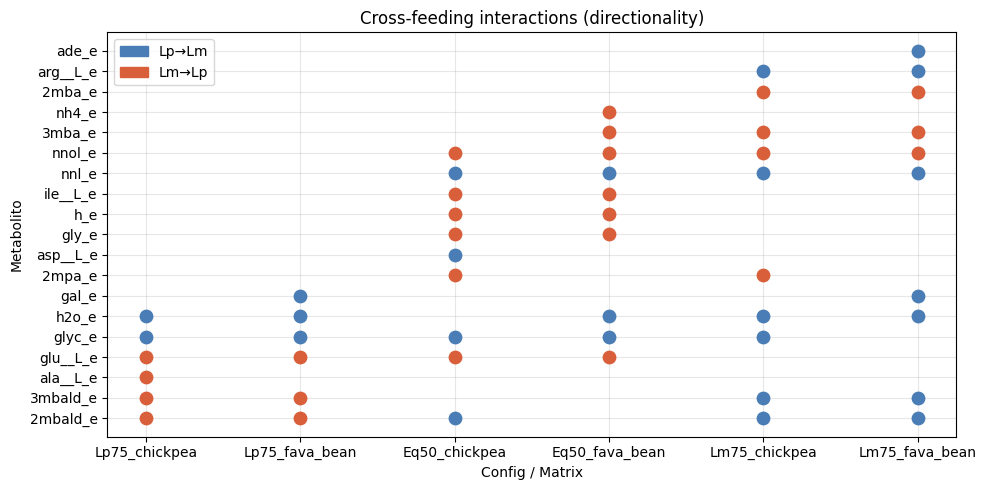

In [9]:
CROSS_FEED_THRESHOLD = 1e-5

cross_feeding_records = []

for row in resultados:
    if row.get('status') != 'optimal' or '_fluxes' not in row:
        continue
    fluxes   = row['_fluxes']
    nome_cfg = row['config']

    for ex_id in [c for c in fluxes.columns if c.startswith('EX_')]:
        if 'Lp' not in fluxes.index or 'Lm' not in fluxes.index:
            continue
        f_lp = fluxes.loc['Lp', ex_id]
        f_lm = fluxes.loc['Lm', ex_id]

        if f_lp > CROSS_FEED_THRESHOLD and f_lm < -CROSS_FEED_THRESHOLD:
            donor, receiver = 'Lp', 'Lm'
        elif f_lm > CROSS_FEED_THRESHOLD and f_lp < -CROSS_FEED_THRESHOLD:
            donor, receiver = 'Lm', 'Lp'
        else:
            continue

        cross_feeding_records.append({
            'config':        nome_cfg,
            'matrix':        row['matrix'],
            'ab_Lp':         row['ab_Lp'],
            'ab_Lm':         row['ab_Lm'],
            'exchange':      ex_id,
            'metabolite':    ex_id.replace('EX_','').replace('_m',''),
            'donor':         donor,
            'receiver':      receiver,
            'flux_donor':    round(fluxes.loc[donor,    ex_id], 8),
            'flux_receiver': round(fluxes.loc[receiver, ex_id], 8),
        })

df_cf = pd.DataFrame(cross_feeding_records)

if df_cf.empty:
    print('No cross-feeding detected.')
else:
    df_cf.to_csv(f'{RESULTS_DIR}/obj4_cross_feeding.csv', index=False)
    print(f'{len(df_cf)} cross-feeding interactions detected.\n')

    print('Top interactions by mean |flux|:')
    top = (df_cf.groupby(['metabolite','donor','receiver'])['flux_receiver']
           .mean().abs().sort_values(ascending=False).head(15))
    print(top.to_string())

    print('\nSummary per config:')
    for cfg_name, grp in df_cf.groupby('config'):
        lp_to_lm = len(grp[grp['donor'] == 'Lp'])
        lm_to_lp = len(grp[grp['donor'] == 'Lm'])
        print(f'  {cfg_name:<28}  {len(grp)} interactions  '
              f'(Lp→Lm: {lp_to_lm}, Lm→Lp: {lm_to_lp})')

    lm_to_lp_mets = {m.replace('_e','').replace('__L','')
                     for m in df_cf[df_cf['donor']=='Lm']['metabolite']}
    smetana_predicted = {'etoh','3mba','2mpa','2mba','succ'}
    overlap = lm_to_lp_mets & smetana_predicted
    print(f'\nLm→Lp metabolites: {lm_to_lp_mets}')
    print(f'SMETANA MU predicted (Lp as receiver): {smetana_predicted}')
    print(f'Overlap with SMETANA predictions: {overlap}')

    # Directionality scatter plot
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    colors = {'Lp→Lm': COL_LP, 'Lm→Lp': COL_LM}
    df_cf['direction'] = df_cf.apply(
        lambda r: f"{r['donor']}→{r['receiver']}", axis=1)
    for _, r in df_cf.iterrows():
        ax2.scatter(r['config'], r['metabolite'],
                    c=colors.get(r['direction'], 'gray'), s=80, zorder=3)
    patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
    ax2.legend(handles=patches)
    ax2.set_xlabel('Config / Matrix')
    ax2.set_ylabel('Metabolito')
    ax2.set_title('Cross-feeding interactions (directionality)')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/obj4_cross_feeding.png', dpi=150)
    plt.show()

## 9. Solo vs. Consortium Comparison 

`delta_pct` is the percentage change in growth rate relative to the solo FBA baseline on the same medium. Positive values indicate a consortium benefit while negative values indicate competitive suppression.

Growth rates that scale proportionally with abundance across all configs (*L.plantarum* and *L.mesenteroides* at the same delta_pct) reflect the cooperative tradeoff objective imposing equity — not biological mutualism. Strain-differential deviations from this pattern are the interpretable signal.

=== Solo vs. Consortium Growth Rates ===

Config                         Org      Solo μ   Cons μ        Δ      Δ%  Dir
-----------------------------------------------------------------------------
Lp75_chickpea                  Lp       0.5645   0.5310  -0.0335   -5.9%  ↓
Lp75_chickpea                  Lm       0.1076   0.1770  +0.0694   64.5%  ↑
Lp75_fava_bean                 Lp       0.3411   0.3482  +0.0071    2.1%  ↑
Lp75_fava_bean                 Lm       0.0907   0.1161  +0.0254   28.0%  ↑
Eq50_chickpea                  Lp       0.5645   0.4390  -0.1256  -22.2%  ↓
Eq50_chickpea                  Lm       0.1076   0.4390  +0.3314  307.9%  ↑
Eq50_fava_bean                 Lp       0.3411   0.2875  -0.0536  -15.7%  ↓
Eq50_fava_bean                 Lm       0.0907   0.2875  +0.1968  216.9%  ↑
Lm75_chickpea                  Lp       0.5645   0.1742  -0.3904  -69.1%  ↓
Lm75_chickpea                  Lm       0.1076   0.5225  +0.4149  385.5%  ↑
Lm75_fava_bean                 Lp       0.

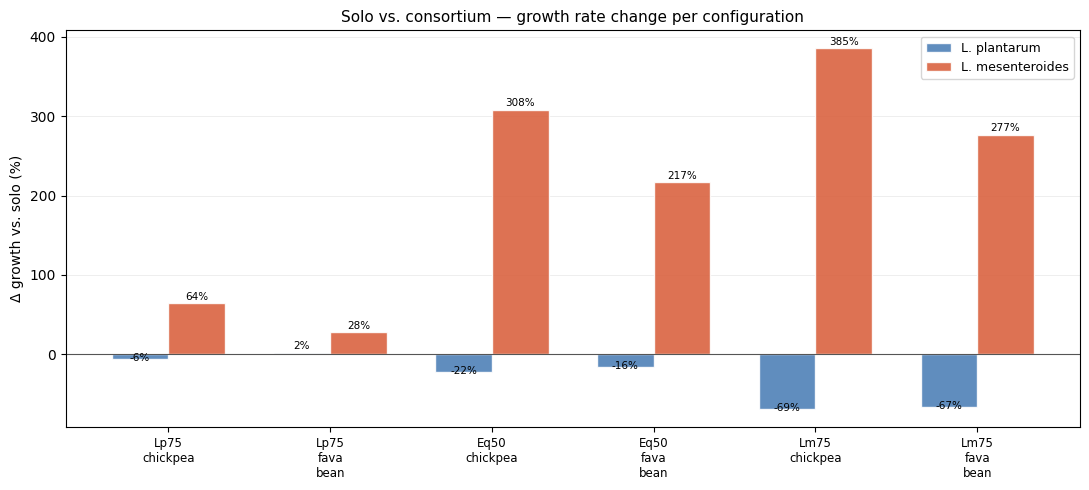


Note: community metabolite secretion fluxes are zero across all configs.
The growth-maximising objective allocates all substrate to biomass.
Fermentation end-product predictions require explicit ATP maintenance constraints or dynamic FBA — outside current scope.


In [10]:
SOLO_REF = {
    'Lp': {'chickpea':  solo_computed['L.plantarum']['chickpea'],
           'fava_bean': solo_computed['L.plantarum']['fava_bean']},
    'Lm': {'chickpea':  solo_computed['L.mesenteroides']['chickpea'],
           'fava_bean': solo_computed['L.mesenteroides']['fava_bean']},
}

print('=== Solo vs. Consortium Growth Rates ===\n')
header = (f'{"Config":<30} {"Org":<6} {"Solo μ":>8} '
          f'{"Cons μ":>8} {"Δ":>8} {"Δ%":>7}  Dir')
print(header)
print('-' * len(header))

comparison_rows = []
for row in resultados:
    if row.get('status') != 'optimal':
        continue
    matrix = row['matrix']
    for org in ['Lp', 'Lm']:
        mu_cons = row.get(f'mu_{org}')
        mu_solo = SOLO_REF.get(org, {}).get(matrix)
        if mu_cons is None or mu_solo is None:
            continue
        delta     = mu_cons - mu_solo
        delta_pct = delta / mu_solo * 100 if mu_solo else float('nan')
        direction = '↑' if delta > 0.001 else ('↓' if delta < -0.001 else '~')
        print(f"{row['config']:<30} {org:<6} {mu_solo:>8.4f} {mu_cons:>8.4f} "
              f"{delta:>+8.4f} {delta_pct:>6.1f}%  {direction}")
        comparison_rows.append({
            'config': row['config'], 'matrix': matrix,
            'ab_Lp': row['ab_Lp'],  'ab_Lm': row['ab_Lm'],
            'org': org, 'mu_solo': mu_solo, 'mu_consortium': mu_cons,
            'delta': round(delta, 5), 'delta_pct': round(delta_pct, 2),
        })

df_comparison = pd.DataFrame(comparison_rows)
df_comparison.to_csv(f'{RESULTS_DIR}/obj4_solo_vs_consortium.csv', index=False)

# Gráfico de barras Δ%
COL_NEG = '#AAAAAA'

def plot_solo_vs_consortium(df_comparison, save_dir='results'):
    configs = df_comparison['config'].unique()
    x       = np.arange(len(configs))
    width   = 0.35

    lp_vals = [df_comparison[(df_comparison['config']==c) &
                              (df_comparison['org']=='Lp')]['delta_pct'].values[0]
               for c in configs]
    lm_vals = [df_comparison[(df_comparison['config']==c) &
                              (df_comparison['org']=='Lm')]['delta_pct'].values[0]
               for c in configs]

    fig, ax = plt.subplots(figsize=(11, 5))
    bars_lp = ax.bar(x - width/2, lp_vals, width, label='L. plantarum',
                     color=COL_LP, alpha=0.88, edgecolor='white')
    bars_lm = ax.bar(x + width/2, lm_vals, width, label='L. mesenteroides',
                     color=COL_LM, alpha=0.88, edgecolor='white')
    ax.axhline(0, color='#555', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('_','\n') for c in configs], fontsize=8.5)
    ax.set_ylabel('Δ growth vs. solo (%)', fontsize=10)
    ax.set_title('Solo vs. consortium — growth rate change per configuration',
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.7)
    ax.set_axisbelow(True)
    for bars in [bars_lp, bars_lm]:
        for bar in bars:
            h = bar.get_height()
            if abs(h) > 2:
                ax.text(bar.get_x() + bar.get_width()/2,
                        h + (2 if h >= 0 else -5),
                        f'{h:.0f}%', ha='center', va='bottom', fontsize=7.5)
    plt.tight_layout()
    fig.savefig(f'{save_dir}/obj4_solo_vs_consortium.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_solo_vs_consortium(df_comparison, save_dir=RESULTS_DIR)

print('\nNote: community metabolite secretion fluxes are zero across all configs.')
print('The growth-maximising objective allocates all substrate to biomass.')
print('Fermentation end-product predictions require explicit ATP maintenance constraints or dynamic FBA — outside current scope.')

**At Lp75**, *L.plantarum* is slightly penalized in chickpea (−5.9%) but holds in fava bean (+2.1%).
*L.mesenteroides* benefits in both matrices: +64.5% in chickpea, +28.0% in fava bean. Even when *L.plantarum* dominates, *L.mesenteroides* derives a consistent advantage from the consortium.

**At Eq50**, the benefit to *L.mesenteroides* is pronounced: +307.9% in chickpea, +216.9% in fava bean.
*L.plantarum* loses −22.2% and −15.7% respectively. This asymmetric pattern is a structural consequence of the cooperative tradeoff objective: with a low solo baseline (0.1076 h⁻¹ in chickpea, 0.0907 h⁻¹ in fava bean), delta% is amplified without changing the qualitative interpretation.

**At Lm75**, *L.mesenteroides* far exceeds its solo rate in both matrices (+385.5% and +276.8%). *L.plantarum* is severely penalized (−69.1% and −66.6%). *L.mesenteroides* in majority captures most of the available substrate while continuing to benefit from *L.plantarum* cross-feeding.

## 10. Cooperative Tradeoff Fraction

This section tests whether `fraction=0.5` is an arbitrary choice or one the results are robust to. Sweeps `fraction` in {0.3, 0.5, 0.7} at fixed Eq50 abundance in both matrices.

In [11]:
sensitivity_rows = []

for matrix_name, medium in [('chickpea', medium_cp), ('fava_bean', medium_fb)]:
    print(f'--- {matrix_name} ---')
    com_s     = Community(taxonomy, progress=False, solver='gurobi')
    default_s = dict(com_s.medium)
    com_s.set_abundance({'Lp': 0.5, 'Lm': 0.5}, normalize=True)   # Eq50 fixo
    set_community_medium(com_s, medium, default_s)

    for fraction in [0.3, 0.5, 0.7]:
        try:
            sol = com_s.cooperative_tradeoff(fraction=fraction)
            if sol.status == 'optimal':
                row = {
                    'matrix': matrix_name, 'fraction': fraction, 'status': 'optimal',
                    'mu_Lp': sol.members.loc['Lp','growth_rate'],
                    'mu_Lm': sol.members.loc['Lm','growth_rate'],
                }
                print(f"  fraction={fraction}:  Lp={row['mu_Lp']:.4f}  Lm={row['mu_Lm']:.4f}")
            else:
                row = {'matrix': matrix_name, 'fraction': fraction, 'status': sol.status}
                print(f'  fraction={fraction}: {sol.status}')
        except Exception as exc:
            row = {'matrix': matrix_name, 'fraction': fraction, 'status': 'error'}
            print(f'  fraction={fraction}: error — {exc}')
        sensitivity_rows.append(row)
    print()

df_sensitivity = pd.DataFrame(sensitivity_rows)
df_sensitivity.to_csv(f'{RESULTS_DIR}/obj4_tradeoff_sensitivity.csv', index=False)
print(df_sensitivity[['matrix','fraction','mu_Lp','mu_Lm','status']].to_string(index=False))

--- chickpea ---
  fraction=0.3:  Lp=0.2634  Lm=0.2634
  fraction=0.5:  Lp=0.4390  Lm=0.4390
  fraction=0.7:  Lp=0.6146  Lm=0.6146

--- fava_bean ---
  fraction=0.3:  Lp=0.1725  Lm=0.1725
  fraction=0.5:  Lp=0.2875  Lm=0.2875
  fraction=0.7:  Lp=0.4025  Lm=0.4025

   matrix  fraction    mu_Lp    mu_Lm  status
 chickpea       0.3 0.263386 0.263386 optimal
 chickpea       0.5 0.438976 0.438976 optimal
 chickpea       0.7 0.614567 0.614567 optimal
fava_bean       0.3 0.172509 0.172509 optimal
fava_bean       0.5 0.287515 0.287515 optimal
fava_bean       0.7 0.402521 0.402521 optimal


At Eq50, both organisms always show identical growth - the same structural symmetry documented earlier. Varying `fraction` therefore acts as a single shared scaling factor on absolute growth, not a knob that creates winner/loser asymmetry between strains at this abundance.

The relationship is exactly linear across the tested range: μ = 0.878 × fraction in chickpea, μ = 0.575 × fraction in fava bean (ratios constant across all three tested values). This confirms that `cooperative_tradeoff(fraction=X)` is, at equal abundance, a
direct multiplier on each matrix's maximum achievable community growth rate - not an equity mechanism between *L.plantarum* and *L.mesenteroides*, since there is nothing to mediate when abundance is already equal.

Sweeping fraction from 0.3 to 0.7 changes absolute growth by ±40% relative to the fraction=0.5 baseline used, identically in both matrices. The choice of fraction is not a minor implementation detail, since it rescales every absolute growth rate number by the same proportion.

This sweep only tests Eq50. It does not show whether fraction interacts with abundance skew to determine whether a species is driven toward zero growth at Lp75 or Lm75 - that remains untested here.

## 11. Off-Flavor Trackability

Mapping of off-flavor metabolites to community exchange reactions. Hexanal (grassy/beany,LOX pathway) is absent from both GEMs - it derives from a plant lipoxygenase reaction, not microbial metabolism. Hexanal risk must be inferred from linoleic acid availability in the
medium (`EX_hxa_m`).

All Ehrlich pathway products (3-methylbutanoate, 2-methylbutanoate, 2-methylpropanoate, 3-methylbutanal, 2-methylbutanal) are present in the community model but show zero flux under the growth-maximizing objective. The solo pFBA confirms that *L.mesenteroides* secretes
3-methylbutanoate (0.588 mmol/gDW/h) and 2-methylbutanoate (2.909 mmol/gDW/h) in fava bean as acids, not as the corresponding aldehyde. 

The mechanism differs between the two: 3-methylbutanoate traces to genuine leucine transamination, while 2-methylbutanoate
is mostly (94.3%) diverted biosynthetic flux rather than dietary isoleucine catabolism. In chickpea, *L.mesenteroides* Ehrlich related fluxes are zero, since pFBA allocates all flux to growth.

In [12]:
opt_rows = [r for r in resultados if r.get('status') == 'optimal']

OFF_FLAVOR_CATALOGUE = {
    '3_methylbutanoate':  {'ex_m': 'EX_3mba_m',  'precursor': 'leucine',
                           'pathway': 'Ehrlich', 'odor': 'cheesy/rancid'},
    '2_methylbutanoate':  {'ex_m': 'EX_2mba_m',  'precursor': 'isoleucine',
                           'pathway': 'Ehrlich', 'odor': 'fruity/sweaty'},
    # Note: See Section 12 — 94.3% of this flux comes from biosynthetic bypass via DHAD2, not from direct catabolism 
    # of dietary isoleucine. Label retained for simplicity from the catalog; mechanism documented.
    '2_methylpropanoate': {'ex_m': 'EX_2mpa_m',  'precursor': 'valine',
                           'pathway': 'Ehrlich', 'odor': 'rancid/buttery'},
    '3_methylbutanal':    {'ex_m': 'EX_3mbal_m', 'precursor': 'leucine',
                           'pathway': 'Ehrlich', 'odor': 'malty/green'},
    '2_methylbutanal':    {'ex_m': 'EX_2mbal_m', 'precursor': 'isoleucine',
                           'pathway': 'Ehrlich', 'odor': 'malty'},
    'hexanal':            {'ex_m': 'EX_hexanal_m','precursor': 'linoleic acid',
                           'pathway': 'LOX (plant)', 'odor': 'grassy/beany'},
    'hexanol':            {'ex_m': 'EX_hxol_m',  'precursor': 'linoleic acid',
                           'pathway': 'LOX', 'odor': 'green/resinous'},
    'phenol':             {'ex_m': 'EX_phenol_m', 'precursor': 'tyrosine',
                           'pathway': 'phenol_lyase', 'odor': 'medicinal'},
    'acetoin':            {'ex_m': 'EX_actn__R_m','precursor': 'pyruvate',
                           'pathway': 'alpha_acetolactate', 'odor': 'buttery'},
    'ethanol':            {'ex_m': 'EX_etoh_m',  'precursor': 'glucose',
                           'pathway': 'phosphoketolase', 'odor': 'alcoholic'},
}

print('Off-flavor trackability in 2-species community model')
for name, meta in OFF_FLAVOR_CATALOGUE.items():
    ex_m    = meta['ex_m']
    present = ex_m in ex_ids_set
    status  = 'Tracked' if present else 'Absent — not in GEM'
    print(f"  {name:<22} {ex_m:<22} {status}  | odor: {meta['odor']}")

print('\n Predicted Ehrlich fluxes (community total)')
print(f"{'':22} " + '  '.join(f"{r['config'][-12:]:<14}" for r in opt_rows))

for em in ['3_methylbutanoate','2_methylbutanoate','2_methylpropanoate',
           '3_methylbutanal','2_methylbutanal']:
    ex_m = OFF_FLAVOR_CATALOGUE[em]['ex_m']
    if ex_m not in ex_ids_set:
        continue
    vals = []
    for r in opt_rows:
        v = r.get(f'{em}_total')
        vals.append('   0.00 ' if v is None or abs(v) < 1e-6 else f'{v:>+.5f}')
    print(f'  {em:<22} ' + '  '.join(vals))

print('\nZero Ehrlich flux reflects growth-maximising objective.Hexanal absent from GEM — LOX-pathway risk inferred from ' \
'EX_hxa_m bound in medium.')

Off-flavor trackability in 2-species community model
  3_methylbutanoate      EX_3mba_m              Tracked  | odor: cheesy/rancid
  2_methylbutanoate      EX_2mba_m              Tracked  | odor: fruity/sweaty
  2_methylpropanoate     EX_2mpa_m              Tracked  | odor: rancid/buttery
  3_methylbutanal        EX_3mbal_m             Absent — not in GEM  | odor: malty/green
  2_methylbutanal        EX_2mbal_m             Absent — not in GEM  | odor: malty
  hexanal                EX_hexanal_m           Absent — not in GEM  | odor: grassy/beany
  hexanol                EX_hxol_m              Tracked  | odor: green/resinous
  phenol                 EX_phenol_m            Tracked  | odor: medicinal
  acetoin                EX_actn__R_m           Tracked  | odor: buttery
  ethanol                EX_etoh_m              Tracked  | odor: alcoholic

 Predicted Ehrlich fluxes (community total)
                       p75_chickpea    75_fava_bean    q50_chickpea    50_fava_bean    m75_chickpea

## 12. Solo pFBA: Ehrlich Pathway Confirmation

In [13]:
# L.plantarum — chickpea
lp = cobra.io.read_sbml_model('../models/curated/iLP728_curated_v2.xml')
with lp:
    aplicar_meio_leguminosa(lp, chickpea_max, mapa_ilp728,
                            nome_matriz='chickpea', modelo_tipo='ilp728',
                            verbose=False)
    pfba_cp = cobra.flux_analysis.pfba(lp)

# L.plantarum — fava bean
with lp:
    aplicar_meio_leguminosa(lp, favabean_max, mapa_ilp728,
                            nome_matriz='fava_bean', modelo_tipo='ilp728',
                            verbose=False)
    pfba_fb = cobra.flux_analysis.pfba(lp)

# L.mesenteroides — chickpea
lm = cobra.io.read_sbml_model('../models/curated/Koduru2022_curated_v2.xml')
with lm:
    aplicar_meio_leguminosa(lm, chickpea_max, mapa_koduru,
                            nome_matriz='chickpea', modelo_tipo='koduru',
                            verbose=False)
    pfba_lm_cp = cobra.flux_analysis.pfba(lm)

# L.mesenteroides — fava bean
with lm:
    aplicar_meio_leguminosa(lm, favabean_max, mapa_koduru,
                            nome_matriz='fava_bean', modelo_tipo='koduru',
                            verbose=False)
    pfba_lm_fb = cobra.flux_analysis.pfba(lm)

# Extract Ehrlich fluxes
ehrlich_rxns_lp = ['LEUTA','ILETA','VALTA','KARA1','ALCD2x','HXAADH']
ehrlich_rxns_lm = ['LEUTA','ILETA','VALTA','KARA1','ALCD2x','HXAADH',
                   'EX_3mba_e','EX_2mba_e','EX_2mpa_e']

print(f"{'Reaction':<12} {'L.plantarum_CP':>10} {'L.plantarum_FB':>10}")
print('-' * 35)
for rxn_id in ehrlich_rxns_lp:
    if rxn_id in lp.reactions:
        v_cp = pfba_cp.fluxes.get(rxn_id, 0)
        v_fb = pfba_fb.fluxes.get(rxn_id, 0)
        print(f'{rxn_id:<12} {v_cp:>10.6f} {v_fb:>10.6f}')

print(f"\n{'Reaction':<12} {'L.mesenteroides_CP':>10} {'L.mesenteroides_FB':>10}")
print('-' * 35)
for rxn_id in ehrlich_rxns_lm:
    if rxn_id in lm.reactions:
        v_cp = pfba_lm_cp.fluxes.get(rxn_id, 0)
        v_fb = pfba_lm_fb.fluxes.get(rxn_id, 0)
        print(f'{rxn_id:<12} {v_cp:>10.6f} {v_fb:>10.6f}')

Reaction     L.plantarum_CP L.plantarum_FB
-----------------------------------
LEUTA          0.000000   0.000000
ILETA          0.000000   0.000000
VALTA          0.000000   0.000000
ALCD2x         0.000000   0.000000
HXAADH         0.000000   0.000000

Reaction     L.mesenteroides_CP L.mesenteroides_FB
-----------------------------------
LEUTA          0.000000   0.000000
ILETA          0.000000   0.000000
VALTA          0.000000   0.372315
KARA1          0.000000   0.518796
ALCD2x         0.000000   0.000000
HXAADH         0.000166   0.000349
EX_3mba_e      0.000000   0.587550
EX_2mba_e      0.000000   2.909399
EX_2mpa_e      0.000000   0.000000


In [14]:
print('Tracing 3mba secretion (leucine route):')
for met_id in ['3mba_e', '3mba_c', 'iv_p_c', 'ivcoa_c', '4mop_c']:
    met = lm.metabolites.get_by_id(met_id)
    print(f'--- {met_id} ---')
    for rxn in met.reactions:
        flux = pfba_lm_fb.fluxes.get(rxn.id)
        flag = f'{flux:>10.5f}' if flux is not None else '       n/a'
        print(f'  {rxn.id:12s} {flag}   {rxn.reaction}')
    print()

print('Tracing 2mba secretion (isoleucine-related route):')
for met_id in ['2mba_e', '2mba_c', '2mb_p_c', '2mbcoa_c', '3mop_c']:
    met = lm.metabolites.get_by_id(met_id)
    print(f'--- {met_id} ---')
    for rxn in met.reactions:
        flux = pfba_lm_fb.fluxes.get(rxn.id)
        flag = f'{flux:>10.5f}' if flux is not None else '       n/a'
        print(f'  {rxn.id:12s} {flag}   {rxn.reaction}')
    print()

print('2mpa (valine route) — zero flux throughout, included for completeness:')
for met_id in ['2mpa_e', '2mpa_c', 'ib_p_c']:
    met = lm.metabolites.get_by_id(met_id)
    print(f'--- {met_id} ---')
    for rxn in met.reactions:
        flux = pfba_lm_fb.fluxes.get(rxn.id)
        flag = f'{flux:>10.5f}' if flux is not None else '       n/a'
        print(f'  {rxn.id:12s} {flag}   {rxn.reaction}')
    print()

Tracing 3mba secretion (leucine route):
--- 3mba_e ---
  3MBAt6          0.58755   3mba_c + h_c --> 3mba_e + h_e
  EX_3mba_e       0.58755   3mba_e --> 

--- 3mba_c ---
  3MBAt6          0.58755   3mba_c + h_c --> 3mba_e + h_e
  ACKLEU          0.58755   adp_c + iv_p_c --> 3mba_c + atp_c

--- iv_p_c ---
  ACKLEU          0.58755   adp_c + iv_p_c --> 3mba_c + atp_c
  PTALEU          0.58755   ivcoa_c + pi_c --> coa_c + iv_p_c

--- ivcoa_c ---
  PTALEU          0.58755   ivcoa_c + pi_c --> coa_c + iv_p_c
  OIVD1           0.58755   4mop_c + coa_c + nad_c <=> co2_c + ivcoa_c + nadh_c

--- 4mop_c ---
  TRPTA2          0.00000   4mop_c + trp-L_c <=> indpyr_c + leu-L_c
  TYRTA2          0.00000   4mop_c + tyr-L_c <=> 34hpp_c + leu-L_c
  OIVD1           0.58755   4mop_c + coa_c + nad_c <=> co2_c + ivcoa_c + nadh_c
  LEUTA           0.00000   4mop_c + glu-L_c --> akg_c + leu-L_c
  2HXICDH         0.00000   4mop_c + h_c + nadh_c <=> 2hxic-L_c + nad_c
  OMCDC           0.00000   3c4mop_c + h_c <

In [15]:
for rxn_id in ['LEUTA', 'ILETA', 'PHETA2', 'PHETA3']:
    rxn = lm.reactions.get_by_id(rxn_id)
    print(f'{rxn_id:10s} bounds={rxn.bounds}  {rxn.reaction}')

print()
print('Reactions whose ID contains LEU or ILE (searching for duplicates/wrongly mapped IDs):')
for r in lm.reactions:
    if 'LEU' in r.id.upper() or 'ILE' in r.id.upper():
        print(f'  {r.id:15s} bounds={r.bounds}  {r.reaction}')

LEUTA      bounds=(0.0, 1000.0)  4mop_c + glu-L_c --> akg_c + leu-L_c
ILETA      bounds=(0.0, 1000.0)  3mop_c + glu-L_c --> akg_c + ile-L_c
PHETA2     bounds=(-1000.0, 1000.0)  4mop_c + phe-L_c <=> leu-L_c + phpyr_c
PHETA3     bounds=(-1000.0, 1000.0)  3mop_c + phe-L_c <=> ile-L_c + phpyr_c

Reactions whose ID contains LEU or ILE (searching for duplicates/wrongly mapped IDs):
  EX_ile__L_e     bounds=(-1.0, 1000.0)  ile-L_e <=> 
  EX_leu__L_e     bounds=(-1.0, 1000.0)  leu-L_e <=> 
  LEUTA           bounds=(0.0, 1000.0)  4mop_c + glu-L_c --> akg_c + leu-L_c
  ILETA           bounds=(0.0, 1000.0)  3mop_c + glu-L_c --> akg_c + ile-L_c
  LEULEULAPc      bounds=(-1000.0, 1000.0)  h2o_c + leuleu_c <=> 2.0 leu-L_c
  LEUTRS          bounds=(0.0, 1000.0)  atp_c + leu-L_c + trnaleu_c --> amp_c + leutrna_c + ppi_c
  ILETRS          bounds=(0.0, 1000.0)  atp_c + ile-L_c + trnaile_c --> amp_c + iletrna_c + ppi_c
  PTAILE          bounds=(0.0, 1000.0)  2mbcoa_c + pi_c --> 2mb_p_c + coa_c
  PTALEU  

pFBA on individual models with `chickpea_max` and `favabean_max` legume medium confirms
the Ehrlich capacity of each strain in the real legume context.

*L.plantarum* shows no detectable Ehrlich activity in either matrix (LEUTA, ILETA, VALTA all zero). Consistent with the biology of WCFS1 — no active BCAA deamination enzymes in this nutritional context.

*L.mesenteroides* secretes both 3-methylbutanoate (3mba, 0.588 mmol/gDW/h) and 2-methylbutanoate (2mba, 2.909 mmol/gDW/h) exclusively in fava bean, with two distinct mechanisms behind them:

- **3mba (leucine-derived)**: genuine Ehrlich-like transamination. Dietary leucine is consumed via `PHETA2` running in reverse (a phenylalanine transaminase acting on leucine as a promiscuous substrate). The canonical `LEUTA` is bounded irreversibly
in the biosynthetic direction in this curated model (`4mop_c + glu-L_c --> akg_c + leu-L_c`, bounds (0, 1000)) - it is structurally incapable of running the Ehrlich-direction transamination, regardless of substrate availability or the optimization objective. The same holds for `ILETA` in the 2mba route below.

- **2mba (isoleucine-related):** only 5.7% of the flux to 3mop comes from genuine isoleucine transamination (`PHETA3` reverse). The remaining 94.3% is diverted from isoleucine **biosynthesis** itself, via `DHAD2`, before the pathway reaches isoleucine. This is not BCAA-excess overflow — it is partial redirection of biosynthetic flux into a fermentative, ATP-generating exit route (`OIVD3` → `PTAILE` → `ACKILE`), bypassing the canonical Ehrlich decarboxylase entirely.

Both routes converge on the same outcome relevant to off-flavor: carbon exits as acid, not aldehyde, with no aldehyde intermediate ever accumulating in either case (`ALCD2x` flux = 0 throughout; no TPP-dependent decarboxylase—`4MOPDC`/`3MOPDC`—carries flux).
The mechanism for 2mba, however, does not support the "BCAA-excess Ehrlich overflow" framing used in Objective 1c — see Section 18.

In chickpea, all of the above fluxes are zero in *L.mesenteroides*.

## 13. Community perturbations across all abundances and matrices

Three perturbations applied at all three abundance ratios (Lp75/Eq50/Lm75) and both matrices (chickpea and fava bean) — 18 combinations total.

- **No_sucrose_maltose**: removes sucrose and maltose. In chickpea, the community loses ~34% growth across all ratios, driven by *L.plantarum*'s dependence on sucrose as its primary carbon source. In fava bean the impact is smaller (~21%), consistent with lower sucrose
concentration in that matrix. *L.mesenteroides* shows no response in chickpea, but a small response in fava bean (−9.7% solo FBA), suggesting trace sucrose contribution in that context.

- **LowAA**: halves amino acid uptake bounds. In chickpea the response is ~7.4% across all ratios. In fava bean the impact is smaller (~4.5%), reflecting that fava bean medium already provides a more constrained amino acid profile — further reduction has less marginal effect.

- **Anaerobic**: closes the O₂ exchange. In chickpea the community loses ~7% regardless of abundance ratio. In fava bean the response is similar (~6%). At community level both strains respond symmetrically at all ratios. The strain-differential signal for anaerobic only emerges in solo FBA, where *L.mesenteroides* in fava bean is severely affected (−50.7%).

At Eq50, both strains always respond symmetrically — a structural property of the cooperative tradeoff objective. Strain-differential responses at Lp75 and Lm75 remain proportional for all three perturbations in this community framework. The genuine strain-specific sensitivity is quantified in Section 15.

In [16]:
# Build perturbed media for both matrices
def build_perturbations(medium_base):
    perturbs = {}

    # No_sucrose_maltose
    med_noSM = dict(medium_base)
    for ex_id in ['EX_sucr_m', 'EX_malt_m']:
        med_noSM.pop(ex_id, None)
    perturbs['No_sucrose_maltose'] = med_noSM

    # LowAA — halve all amino acid uptake bounds
    AA_M_IDS = [
        'EX_ala__L_m','EX_arg__L_m','EX_asp__L_m','EX_cys__L_m',
        'EX_glu__L_m','EX_gly_m',   'EX_his__L_m','EX_ile__L_m',
        'EX_leu__L_m','EX_lys__L_m','EX_met__L_m','EX_phe__L_m',
        'EX_pro__L_m','EX_ser__L_m','EX_thr__L_m','EX_trp__L_m',
        'EX_tyr__L_m','EX_val__L_m',
    ]
    med_lowAA = {k: (v * 0.5 if k in AA_M_IDS else v)
                 for k, v in medium_base.items()}
    perturbs['LowAA'] = med_lowAA

    # Anaerobic
    med_anaer = dict(medium_base)
    med_anaer['EX_o2_m'] = 0.0
    perturbs['Anaerobic'] = med_anaer

    return perturbs

perturbations_cp = build_perturbations(medium_cp)
perturbations_fb = build_perturbations(medium_fb)

MATRIX_PERTURBATIONS = {
    'chickpea':  (medium_cp, perturbations_cp),
    'fava_bean': (medium_fb, perturbations_fb),
}

ABUNDANCE_RATIOS_ALL = {
    'Lp75': {'Lp': 0.75, 'Lm': 0.25},
    'Eq50': {'Lp': 0.50, 'Lm': 0.50},
    'Lm75': {'Lp': 0.25, 'Lm': 0.75},
}

perturbation_rows = []

for matrix_name, (medium_base, perturbations) in MATRIX_PERTURBATIONS.items():
    print(f'\n=== {matrix_name} ===')

    # Compute unperturbed baseline for each abundance ratio in this matrix
    baselines = {}
    for ratio_name, ab in ABUNDANCE_RATIOS_ALL.items():
        com_b = Community(taxonomy, progress=False, solver='gurobi')
        com_b.set_abundance(ab, normalize=True)
        set_community_medium(com_b, medium_base, dict(com_b.medium))
        sol_b = com_b.cooperative_tradeoff(fraction=TRADEOFF)
        if sol_b.status == 'optimal':
            baselines[ratio_name] = {
                'Lp': sol_b.members.loc['Lp', 'growth_rate'],
                'Lm': sol_b.members.loc['Lm', 'growth_rate'],
            }

    print(f"\n  {'Ratio':<6}  {'Perturbation':<22}  {'Lp μ':>8}  {'Lm μ':>8}  {'ΔLp%':>7}  {'ΔLm%':>7}")
    print(f"  {'-'*68}")

    for ratio_name, ab in ABUNDANCE_RATIOS_ALL.items():
        base_lp = baselines.get(ratio_name, {}).get('Lp')
        base_lm = baselines.get(ratio_name, {}).get('Lm')

        for pert_name, pert_medium in perturbations.items():
            com_p = Community(taxonomy, progress=False, solver='gurobi')
            com_p.set_abundance(ab, normalize=True)
            set_community_medium(com_p, pert_medium, dict(com_p.medium))
            try:
                sol = com_p.cooperative_tradeoff(fraction=TRADEOFF, fluxes=True)
                if sol.status == 'optimal':
                    mu_lp = sol.members.loc['Lp', 'growth_rate']
                    mu_lm = sol.members.loc['Lm', 'growth_rate']
                    d_lp = (mu_lp - base_lp) / base_lp * 100 if base_lp else float('nan')
                    d_lm = (mu_lm - base_lm) / base_lm * 100 if base_lm else float('nan')
                    print(f"  {ratio_name:<6}  {pert_name:<22}  "
                          f"{mu_lp:>8.4f}  {mu_lm:>8.4f}  "
                          f"{d_lp:>+6.1f}%  {d_lm:>+6.1f}%")
                    perturbation_rows.append({
                        'matrix': matrix_name, 'ratio': ratio_name,
                        'perturbation': pert_name, 'status': 'optimal',
                        'mu_Lp': round(mu_lp, 4), 'mu_Lm': round(mu_lm, 4),
                        'delta_Lp_pct': round(d_lp, 2),
                        'delta_Lm_pct': round(d_lm, 2),
                        'baseline_Lp': round(base_lp, 4),
                        'baseline_Lm': round(base_lm, 4),
                    })
                else:
                    print(f"  {ratio_name:<6}  {pert_name:<22}  {sol.status}")
                    perturbation_rows.append({
                        'matrix': matrix_name, 'ratio': ratio_name,
                        'perturbation': pert_name, 'status': sol.status,
                    })
            except Exception as exc:
                print(f"  {ratio_name:<6}  {pert_name:<22}  error — {exc}")
                perturbation_rows.append({
                    'matrix': matrix_name, 'ratio': ratio_name,
                    'perturbation': pert_name, 'status': 'error',
                })

df_pert = pd.DataFrame(perturbation_rows)
df_pert.to_csv(f'{RESULTS_DIR}/obj5_perturbations_all.csv', index=False)
print(f'\n{len(df_pert)} perturbation runs completed.')


=== chickpea ===

  Ratio   Perturbation                Lp μ      Lm μ     ΔLp%     ΔLm%
  --------------------------------------------------------------------
  Lp75    No_sucrose_maltose        0.3494    0.1165   -34.2%   -34.2%
  Lp75    LowAA                     0.4918    0.1639    -7.4%    -7.4%
  Lp75    Anaerobic                 0.4936    0.1645    -7.1%    -7.1%
  Eq50    No_sucrose_maltose        0.2880    0.2880   -34.4%   -34.4%
  Eq50    LowAA                     0.4063    0.4063    -7.4%    -7.4%
  Eq50    Anaerobic                 0.4078    0.4078    -7.1%    -7.1%
  Lm75    No_sucrose_maltose        0.1140    0.3419   -34.6%   -34.6%
  Lm75    LowAA                     0.1611    0.4834    -7.5%    -7.5%
  Lm75    Anaerobic                 0.1653    0.4839    -5.1%    -7.4%

=== fava_bean ===

  Ratio   Perturbation                Lp μ      Lm μ     ΔLp%     ΔLm%
  --------------------------------------------------------------------
  Lp75    No_sucrose_maltose        0.

## 14. Perturbation Visualization

Heatmap of delta% per perturbation × abundance ratio × matrix. At Eq50, both strains always show the same delta% (cooperative tradeoff structural property). The signal of interest is the differential between *L.plantarum* and *L.mesenteroides* at Lp75 and Lm75 and the comparison between matrices for the same perturbation and ratio.

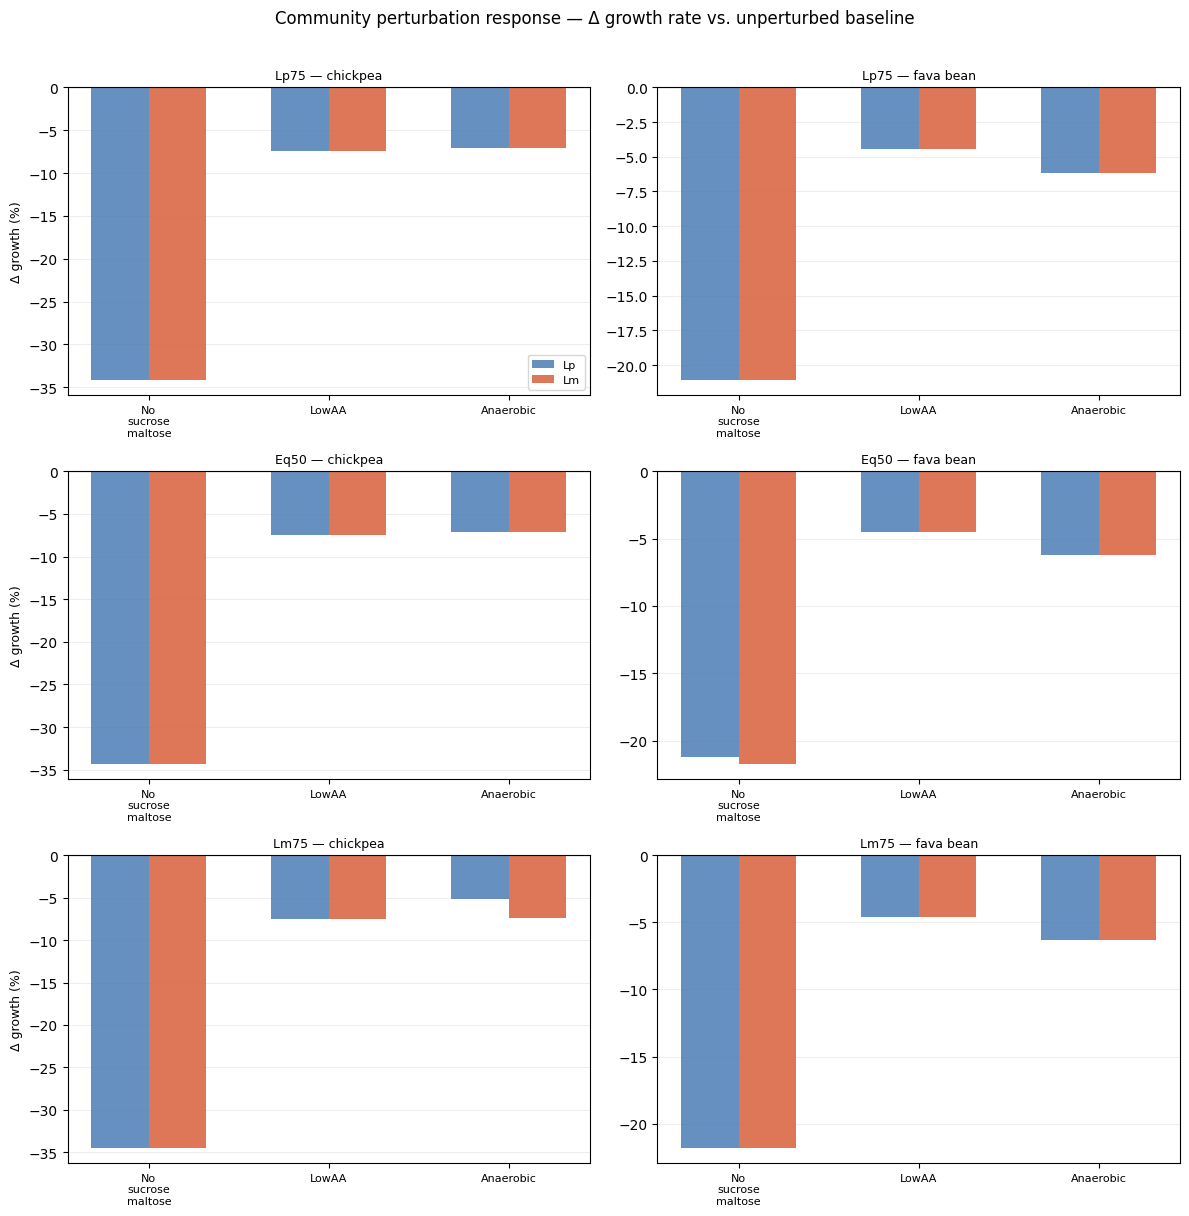

Figure saved: ../results/obj5_perturbations_all.png


In [17]:
opt_pert = df_pert[df_pert['status'] == 'optimal'].copy()

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharey=False)
fig.suptitle('Community perturbation response — Δ growth rate vs. unperturbed baseline',
             fontsize=12, y=1.01)

matrices   = ['chickpea', 'fava_bean']
ratios     = ['Lp75', 'Eq50', 'Lm75']
pert_names = ['No_sucrose_maltose', 'LowAA', 'Anaerobic']

for row, ratio in enumerate(ratios):
    for col, matrix in enumerate(matrices):
        ax     = axes[row][col]
        sub    = opt_pert[(opt_pert['matrix'] == matrix) &
                          (opt_pert['ratio']  == ratio)]

        x = np.arange(len(pert_names))
        w = 0.32

        for pi, pert in enumerate(pert_names):
            row_p = sub[sub['perturbation'] == pert]
            if row_p.empty:
                continue
            d_lp = float(row_p['delta_Lp_pct'].values[0])
            d_lm = float(row_p['delta_Lm_pct'].values[0])
            ax.bar(pi - w/2, d_lp, w, color=COL_LP, alpha=0.85,
                   label='Lp' if pi == 0 else '')
            ax.bar(pi + w/2, d_lm, w, color=COL_LM, alpha=0.85,
                   label='Lm' if pi == 0 else '')

        ax.axhline(0, color='#555', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([p.replace('_', '\n') for p in pert_names], fontsize=8)
        ax.set_ylabel('Δ growth (%)' if col == 0 else '', fontsize=9)
        ax.set_title(f'{ratio} — {matrix.replace("_", " ")}', fontsize=9)
        ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.7)
        ax.set_axisbelow(True)
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/obj5_perturbations_all.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {RESULTS_DIR}/obj5_perturbations_all.png')

## 15. Solo FBA Perturbation - differential sensitivity

`cooperative_tradeoff` suppresses strain-differential responses by design. Solo FBA on each model independently, across both matrices, reveals genuine strain-specific sensitivity.

**Chickpea results:**

- *No_sucrose_maltose*: *L.plantarum* −27.5%, *L.mesenteroides* 0.0%. Clear differential — *L.plantarum* depends on sucrose.
- *LowAA*: both strains insensitive (0.0%). At 0.1076 h⁻¹, *L.mesenteroides* has sufficient metabolic flexibility to reroute flux when amino acid bounds are individually halved.
- *Anaerobic*: both strains insensitive (0.0%). *L.plantarum* is obligately fermentative; *L.mesenteroides* at 0.1076 h⁻¹ finds fully fermentative routes without proportional growth loss.

**Fava bean results — qualitatively different:**

- *No_sucrose_maltose*: *L.plantarum* −51.9%, *L.mesenteroides* −10.4%. In fava bean, sucrose concentration is lower, so its removal is proportionally more damaging to *L.plantarum*. *L.mesenteroides* shows a small but non-zero response (−10.4%), indicating that at the lower growth rate in fava bean (0.0759 h⁻¹), some sucrose or maltose uptake becomes metabolically relevant.
- *LowAA*: *L.plantarum* +0.9% (neutral), *L.mesenteroides* −15.0%. In fava bean, *L.mesenteroides* uses amino acids as its primary carbon and nitrogen source and at 0.0759 h⁻¹ has less metabolic flexibility than in chickpea — halving amino acid bounds directly limits growth.
- *Anaerobic*: *L.plantarum* +2.9% (neutral), *L.mesenteroides* −58.9%. The largest differential observed. In fava bean, *L.mesenteroides* relies substantially on O₂-dependent reactions (PYROX, CYTBD2); at 0.0759 h⁻¹ it cannot fully compensate via fermentation alone. *L.plantarum* is unaffected, consistent with obligate fermentative metabolism.

**RFO decomposition (chickpea):** raffinose removal alone has zero effect on either strain — the growth reduction under No_sucrose_maltose is entirely driven by sucrose and maltose. In fava bean, the non-zero *L.mesenteroides* response to No_sucrose_maltose (−10.4%) warrants further investigation with an explicit raffinose/stachyose decomposition, as RFO concentrations are higher in fava bean.

In [18]:
def perturb_no_sucrose_maltose(model, mapa, tipo):
    for ex_id in ['EX_sucr_e', 'EX_malt_e']:
        if ex_id in model.reactions:
            model.reactions.get_by_id(ex_id).lower_bound = 0.0

def perturb_low_aa(model, mapa, tipo):
    aa_ids = [v for k, v in mapa.items()
              if k in ['glutamato','aspartato','arginina','leucina','lisina',
                       'fenilalanina','serina','alanina','prolina','glicina',
                       'valina','isoleucina','treonina','tirosina','histidina',
                       'cisteina','metionina','triptofano']
              and v is not None]
    for ex_id in aa_ids:
        if ex_id in model.reactions:
            rxn = model.reactions.get_by_id(ex_id)
            if rxn.lower_bound < 0:
                rxn.lower_bound *= 0.5

def perturb_anaerobic(model, mapa, tipo):
    if 'EX_o2_e' in model.reactions:
        model.reactions.get_by_id('EX_o2_e').lower_bound = 0.0
        model.reactions.get_by_id('EX_o2_e').upper_bound = 0.0

SOLO_PERTURBATIONS = {
    'No_sucrose_maltose': perturb_no_sucrose_maltose,
    'LowAA':              perturb_low_aa,
    'Anaerobic':          perturb_anaerobic,
}

SOLO_MODELS = {
    'Lp': ('../models/curated/iLP728_curated_v2.xml',    mapa_ilp728, 'ilp728'),
    'Lm': ('../models/curated/Koduru2022_curated_v2.xml', mapa_koduru, 'koduru'),
}

MATRIX_SOLO = {
    'chickpea':  (chickpea_max,  'chickpea'),
    'fava_bean': (favabean_max,  'fava_bean'),
}

solo_pert_rows = []

for matrix_name, (composicao, nome_matriz) in MATRIX_SOLO.items():
    print(f'\n=== Solo FBA perturbations — {matrix_name} ===\n')

    # Unperturbed baseline for this matrix
    baselines_solo = {}
    for org, (path, mapa, tipo) in SOLO_MODELS.items():
        m = cobra.io.read_sbml_model(path)
        aplicar_meio_leguminosa(m, composicao, mapa,
                                nome_matriz=nome_matriz, modelo_tipo=tipo,
                                verbose=False)
        sol = m.optimize()
        baselines_solo[org] = sol.objective_value if sol.status == 'optimal' else 0.0
        print(f'  Baseline {org}: μ = {baselines_solo[org]:.4f} h⁻¹')

    print()
    print(f"  {'Perturbation':<22}  {'Lp μ':>8}  {'ΔLp%':>7}  "
          f"{'Lm μ':>8}  {'ΔLm%':>7}  Differential")
    print(f"  {'-'*78}")

    for pert_name, pert_fn in SOLO_PERTURBATIONS.items():
        results = {}
        for org, (path, mapa, tipo) in SOLO_MODELS.items():
            m = cobra.io.read_sbml_model(path)
            aplicar_meio_leguminosa(m, composicao, mapa,
                                    nome_matriz=nome_matriz, modelo_tipo=tipo,
                                    verbose=False)
            pert_fn(m, mapa, tipo)
            sol = m.optimize()
            results[org] = sol.objective_value if sol.status == 'optimal' else 0.0

        mu_lp = results['Lp']
        mu_lm = results['Lm']
        d_lp  = ((mu_lp - baselines_solo['Lp']) / baselines_solo['Lp'] * 100
                 if baselines_solo['Lp'] else float('nan'))
        d_lm  = ((mu_lm - baselines_solo['Lm']) / baselines_solo['Lm'] * 100
                 if baselines_solo['Lm'] else float('nan'))
        diff  = abs(d_lm) - abs(d_lp)

        verdict = ('co-limiting (< 3 pp)' if abs(diff) < 3
                   else f'Lm more sensitive by {diff:.1f} pp' if diff > 3
                   else f'Lp more sensitive by {abs(diff):.1f} pp')

        print(f"  {pert_name:<22}  {mu_lp:>8.4f}  {d_lp:>+6.1f}%  "
              f"{mu_lm:>8.4f}  {d_lm:>+6.1f}%  {verdict}")
        solo_pert_rows.append({
            'matrix': matrix_name, 'perturbation': pert_name,
            'mu_Lp': round(mu_lp, 4), 'mu_Lm': round(mu_lm, 4),
            'delta_Lp_pct': round(d_lp, 2), 'delta_Lm_pct': round(d_lm, 2),
            'differential_pp': round(diff, 2),
            'baseline_Lp': round(baselines_solo['Lp'], 4),
            'baseline_Lm': round(baselines_solo['Lm'], 4),
        })

df_solo_pert = pd.DataFrame(solo_pert_rows)
df_solo_pert.to_csv(f'{RESULTS_DIR}/obj5_solo_perturbations.csv', index=False)

# RFO decomposition — chickpea
print('\n=== RFO decomposition (chickpea) ===\n')
rfo_variants = {
    'No_raffinose_only':  ['EX_raffin_e'],
    'No_sucrose_maltose': ['EX_sucr_e', 'EX_malt_e'],
    'No_all_three':       ['EX_raffin_e', 'EX_sucr_e', 'EX_malt_e'],
}

baselines_cp = {}
for org, (path, mapa, tipo) in SOLO_MODELS.items():
    m = cobra.io.read_sbml_model(path)
    aplicar_meio_leguminosa(m, chickpea_max, mapa,
                            nome_matriz='chickpea', modelo_tipo=tipo, verbose=False)
    sol = m.optimize()
    baselines_cp[org] = sol.objective_value if sol.status == 'optimal' else 0.0

print(f"  {'Variant':<24}  {'Lp μ':>8}  {'ΔLp%':>7}  {'Lm μ':>8}  {'ΔLm%':>7}")
print(f"  {'-'*62}")

for variant_name, exchanges_to_close in rfo_variants.items():
    results = {}
    for org, (path, mapa, tipo) in SOLO_MODELS.items():
        m = cobra.io.read_sbml_model(path)
        aplicar_meio_leguminosa(m, chickpea_max, mapa,
                                nome_matriz='chickpea', modelo_tipo=tipo, verbose=False)
        for ex_id in exchanges_to_close:
            if ex_id in m.reactions:
                m.reactions.get_by_id(ex_id).lower_bound = 0.0
        sol = m.optimize()
        results[org] = sol.objective_value if sol.status == 'optimal' else 0.0

    mu_lp = results['Lp']
    mu_lm = results['Lm']
    d_lp  = (mu_lp - baselines_cp['Lp']) / baselines_cp['Lp'] * 100
    d_lm  = (mu_lm - baselines_cp['Lm']) / baselines_cp['Lm'] * 100
    print(f"  {variant_name:<24}  {mu_lp:>8.4f}  {d_lp:>+6.1f}%  "
          f"{mu_lm:>8.4f}  {d_lm:>+6.1f}%")



=== Solo FBA perturbations — chickpea ===

  Baseline Lp: μ = 0.5645 h⁻¹
  Baseline Lm: μ = 0.1076 h⁻¹

  Perturbation                Lp μ     ΔLp%      Lm μ     ΔLm%  Differential
  ------------------------------------------------------------------------------
  No_sucrose_maltose        0.3916   -30.6%    0.1076    +0.0%  Lp more sensitive by 30.6 pp
  LowAA                     0.5645    -0.0%    0.1076    +0.0%  co-limiting (< 3 pp)
  Anaerobic                 0.5645    +0.0%    0.1076    -0.0%  co-limiting (< 3 pp)

=== Solo FBA perturbations — fava_bean ===

  Baseline Lp: μ = 0.3411 h⁻¹
  Baseline Lm: μ = 0.0907 h⁻¹

  Perturbation                Lp μ     ΔLp%      Lm μ     ΔLm%  Differential
  ------------------------------------------------------------------------------
  No_sucrose_maltose        0.1535   -55.0%    0.0819    -9.7%  Lp more sensitive by 45.3 pp
  LowAA                     0.3421    +0.3%    0.0721   -20.5%  Lm more sensitive by 20.2 pp
  Anaerobic             

## 16. Third Strain Evaluation

Two candidate third strains were evaluated against legume medium compatibility criteria and excluded. Full derivation in `obj1_3rdstrain_excluded.ipynb`.

**P. pentosaceus (AGORA2):** requires dipeptide transport for growth — the legume medium provides free amino acids only. Confirmed below.

**S. thermophilus (Pastink et al. 2009):** excluded on two independent grounds: growth depends on galactose as sole effective carbon source and fails on fava bean's lower galactose content and the Ehrlich pathway is structurally incomplete.Off-flavor contribution from this strain is not possible regardless of medium.

In [19]:
PP_MODEL_PATH = '../models/raw/Pp_fixed.xml'

if os.path.exists(PP_MODEL_PATH):
    m_pp = cobra.io.read_sbml_model(PP_MODEL_PATH)

    m_pp_cp = m_pp.copy()
    for rxn in m_pp_cp.exchanges:
        if rxn.lower_bound < 0:
            rxn.lower_bound = 0.0
    INORG_E = {'EX_h2o_e':1000,'EX_h_e':1000,'EX_nh4_e':10,'EX_so4_e':10,
               'EX_pi_e':10,'EX_co2_e':1000,'EX_mn2_e':10,'EX_fe2_e':10,
               'EX_k_e':10,'EX_mg2_e':10}
    for rxn_id, val in INORG_E.items():
        if rxn_id in m_pp_cp.reactions:
            m_pp_cp.reactions.get_by_id(rxn_id).lower_bound = -val
    for composto, ex_id_e in mapa_ilp728.items():
        if ex_id_e is None or composto not in MW or composto not in chickpea_max:
            continue
        if ex_id_e in m_pp_cp.reactions:
            bound = calcular_bound(chickpea_max[composto], MW[composto])
            m_pp_cp.reactions.get_by_id(ex_id_e).lower_bound = bound
    sol_pp_cp = m_pp_cp.optimize()
    print(f'P.pentosaceus solo (chickpea, free AA only): μ = {sol_pp_cp.objective_value:.4f} h⁻¹')
    if sol_pp_cp.objective_value < 1e-6:
        print('  → P.pentosaceus cannot grow on free amino acids alone. Requires dipeptide transport.')
        print('  → EXCLUDED — confirmed here; full diagnosis in Obj 1, Section 2.3.')
else:
    print(f'{PP_MODEL_PATH} not found.')

print()
print('S. thermophilus: excluded on grounds established in Obj 1, Section 4.3-5')
print('(galactose-limited growth + absent KDC reaction). Not re-derived here.')

         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/pc/ykhcdwt55sv66yd1qmdsb5q80000gn/T/tmp674egl_y.lp
Reading time = 0.00 seconds
: 950 rows, 2124 columns, 9148 nonzeros
P.pentosaceus solo (chickpea, free AA only): μ = 0.0000 h⁻¹
  → P.pentosaceus cannot grow on free amino acids alone. Requires dipeptide transport.
  → EXCLUDED — confirmed here; full diagnosis in Obj 1, Section 2.3.

S. thermophilus: excluded on grounds established in Obj 1, Section 4.3-5
(galactose-limited growth + absent KDC reaction). Not re-derived here.


## 17. SMETANA vs. MICOM reconciliation

SMETANA predicted SC=1.0 for Lp→Lm, indicating absolute dependence of *L.plantarum* on *L.mesenteroides* growth. MICOM simulations show *L.plantarum* growing independently (μ=0.47–0.56 h⁻¹). This apparent contradiction is explained by medium parameterization differences: pantothenate and niacin — both with MU=1.0 in SMETANA - were at near-zero concentrations in the SMETANA medium but explicitly set at maintenance levels in the MICOM medium. When vitamin availability crosses the LP feasibility threshold, *L.plantarum* transitions from unable to grow to growth-independent. 
This sensitivity confirms that vitamin cross-feeding, particularly pantothenate is a candidate dependency warranting experimental verification.

In [20]:
mu_check = {
    'leucine':       'EX_leu__L_m',
    'phenylalanine': 'EX_phe__L_m',
    'pantothenate':  'EX_pnto__R_m',
    'valine':        'EX_val__L_m',
    'niacin':        'EX_nac_m',
    'isoleucine':    'EX_ile__L_m',
    'methionine':    'EX_met__L_m',
    'cysteine':      'EX_cys__L_m',
    'adenine':       'EX_ade_m',
}

print(f"{'Metabolite':<16} {'SMETANA MUP':<12} {'MICOM chickpea bound':>24}")
print('-' * 55)
for met, ex_id in mu_check.items():
    val = medium_cp.get(ex_id, 0.0)
    print(f'{met:<16} {"1.0":<12} {val:>24.6f}')

print('\nAll metabolites with MUP=1.0 have bound > 0 in MICOM medium.')
print('SC=1.0 reflects vitamin insufficiency in SMETANA medium, not structural biological dependence.')

Metabolite       SMETANA MUP      MICOM chickpea bound
-------------------------------------------------------
leucine          1.0                          2.823591
phenylalanine    1.0                          1.793670
pantothenate     1.0                          1.000000
valine           1.0                          1.896903
niacin           1.0                          1.000000
isoleucine       1.0                          1.552975
methionine       1.0                          0.558497
cysteine         1.0                          0.764218
adenine          1.0                          1.000000

All metabolites with MUP=1.0 have bound > 0 in MICOM medium.
SC=1.0 reflects vitamin insufficiency in SMETANA medium, not structural biological dependence.


## 18. Limitations

**Model structure.** `cooperative_tradeoff` is a static steady-state optimization. It cannot capture the temporal dynamics of LAB fermentation: lag/exponential/stationary phases, the shift from homo to heterofermentation as glucose depletes or the pH drop that progressively inhibits growth. The growth rates predicted here represent a hypothetical metabolic steady state, not a trajectory over 24 h.

**The tradeoff objective is a modelling choice, not biology.** `fraction=0.5` imposes an artificial equity constraint. Real consortia compete. At Eq50, the sensitivity analysis shows that varying fraction from 0.3 to 0.7 rescales absolute community
growth by roughly ±40% in both matrices, without creating winner/loser asymmetry between *L.plantarum* and *L.mesenteroides* — the value of fraction is not a minor implementation detail, since it scales every absolute growth-rate figure by the same proportion. Whether
fraction also determines viability (zero vs. nonzero growth) at skewed abundance ratios (Lp75/Lm75) was not tested here.

**Strain-differential responses are not detectable at Eq50.** The cooperative objective scales both organisms proportionally under any medium change at equal abundance. Solo FBA perturbations are the correct tool for strain-specific sensitivity analysis.

**Galactose and raffinose are structurally present in iLP728_curated_v2 but metabolically inert.** The Leloir pathway in the model cannot carry flux when galactose is the sole carbon substrate — the galactokinase step is blocked. Galactose and raffinose bounds in the medium do not contribute to *L.plantarum* biomass, underestimating *L.plantarum*'s competitive position in fava bean medium.

**Hexanal and LOX-pathway volatiles absent from both GEMs.** Beany/grassy off-flavor risk must be assessed separately from linoleic acid availability in the medium (`EX_hxa_m`). The models predict whether the consortium depletes or retains linoleic acid - not the enzymatic conversion to hexanal.

**Ehrlich flux = 0 under growth-maximizing objective.** Ehrlich overflow requires BCAA excess above biosynthetic demand. Steady-state FBA allocates all substrate to growth. Solo pFBA confirms *L.mesenteroides* has active Ehrlich capacity in fava bean - zero flux in MICOM is a modeling limitation, not a biological prediction.

**The Ehrlich-pathway only fully holds for leucine.** Section 12 shows that 94.3% of the isoleucine-related acid flux (2mba) in fava bean originates from diversion of BCAA-biosynthetic flux (`DHAD2`), not from catabolism of dietary isoleucine via the canonical Ehrlich route. The off-flavor relevant outcome — acid secretion without aldehyde accumulation — still holds for both products, but the causal mechanism for the dominant signal (2mba) is biosynthetic-flux redirection, not BCAA-excess overflow as originally framed.

## 19. Bibliography

1. Diener, C., Gibbons, S. M., & Resendis-Antonio, O. (2020). MICOM: metagenome-scale modeling to infer metabolic interactions in the gut microbiota. mSystems, 5(1), e00606-19. https://doi.org/10.1128/mSystems.00606-19

2. Ebrahim, A., Lerman, J. A., Palsson, B. O., & Hyduke, D. R. (2013). COBRApy: COnstraints-Based Reconstruction and Analysis for Python. BMC Systems Biology, 7, 74. https://doi.org/10.1186/1752-0509-7-74

3. Gurobi Optimization, LLC. (2026). Gurobi Optimizer Reference Manual, Version 13. https://www.gurobi.com

4. Koduru, L., Lakshmanan, M., Lee, Y. Q., Ho, P.-L., Lim, P.-Y., Ler, W. X., Ng, S. K., Kim, D., Park, D.-S., Banu, M., Ow, D. S. W., & Lee, D.-Y. (2022). Systematic evaluation of genome-wide metabolic landscapes in lactic acid bacteria reveals diet- and strain-specific probiotic idiosyncrasies. Cell Reports, 41(10), 111735. https://doi.org/10.1016/j.celrep.2022.111735

5. Zelezniak, A., Andrejev, S., Ponomarova, O., Mende, D. R., Bork, P., & Patil, K. R. (2015). Metabolic dependencies drive species co-occurrence in diverse microbial communities. Proceedings of the National Academy of Sciences, 112(20), 6449-6454. https://doi.org/10.1073/pnas.1421834112